In [1]:
!pip install indic-nlp-library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.3 MB/s eta 0:00:00


In [3]:
# Cell 1: Imports & setup
import json, re, string
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from indicnlp.tokenize import indic_tokenize
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.transliterate.unicode_transliterate import UnicodeIndicTransliterator
from tqdm import tqdm

In [9]:
# Cell 2: Load JSON train + test data
def load_json(paths, lp="English-Hindi"):
    with open(paths[0], 'r', encoding='utf-8') as file:
        data = json.load(file)

    src_train, tgt_train, src_val, tgt_val, id_train, id_val = [], [], [], [], [], []

    for language_pair, language_data in data.items():
        if language_pair == lp:
            for data_type, data_entries in language_data.items():
                for entry_id, entry_data in data_entries.items():
                    source, target = entry_data["source"], entry_data.get("target", "")
                    if data_type == "Validation":
                        src_val.append(source); tgt_val.append(target); id_val.append(entry_id)
                    else:
                        src_train.append(source); tgt_train.append(target); id_train.append(entry_id)

    # Test file (contains only source)
    with open(paths[1], 'r', encoding='utf-8') as file:
        data = json.load(file)
    for language_pair, language_data in data.items():
        if language_pair == lp:
            for data_type, data_entries in language_data.items():
                for entry_id, entry_data in data_entries.items():
                    source = entry_data["source"]
                    if data_type == "Test":
                        src_val.append(source); id_val.append(entry_id)

    print(f"✅ Loaded {lp}")
    print(f"Train: {len(src_train)} pairs | Test: {len(src_val)} srcs, {len(tgt_val)} tgts (if available)")
    return src_train, tgt_train, src_val, tgt_val


In [10]:
# Cell 3: Load both pairs
train_json = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
test_json  = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

en_hi_train_src, en_hi_train_tgt, en_hi_test_src, en_hi_test_tgt = load_json([train_json, test_json], "English-Hindi")
en_bn_train_src, en_bn_train_tgt, en_bn_test_src, en_bn_test_tgt = load_json([train_json, test_json], "English-Bengali")

✅ Loaded English-Hindi
Train: 80797 pairs | Test: 23085 srcs, 0 tgts (if available)
✅ Loaded English-Bengali
Train: 68849 pairs | Test: 19672 srcs, 0 tgts (if available)


{'lang': 'English (EN→HI Source)', 'count': 80797, 'avg_len': 17.067675780041338, 'median_len': 16.0, 'max_len': 257}
{'lang': 'Hindi (EN→HI Target)', 'count': 80797, 'avg_len': 18.931767268586704, 'median_len': 17.0, 'max_len': 216}
{'lang': 'English (EN→BN Source)', 'count': 68849, 'avg_len': 16.823033014277623, 'median_len': 16.0, 'max_len': 100}
{'lang': 'Bengali (EN→BN Target)', 'count': 68849, 'avg_len': 14.272422257403884, 'median_len': 13.0, 'max_len': 84}


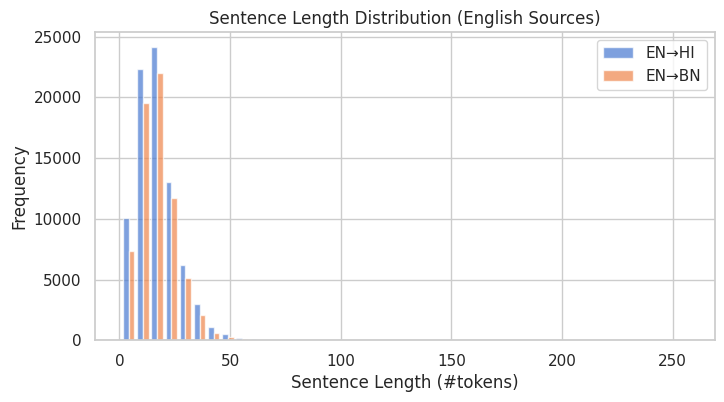

In [11]:
# Cell 4: Sentence length stats and plots
def sentence_length_stats(sentences, lang="English"):
    lengths = [len(s.split()) for s in sentences]
    return {
        "lang": lang,
        "count": len(lengths),
        "avg_len": np.mean(lengths),
        "median_len": np.median(lengths),
        "max_len": np.max(lengths)
    }, lengths

stats_hi_src, hi_src_lengths = sentence_length_stats(en_hi_train_src, "English (EN→HI Source)")
stats_hi_tgt, hi_tgt_lengths = sentence_length_stats(en_hi_train_tgt, "Hindi (EN→HI Target)")
stats_bn_src, bn_src_lengths = sentence_length_stats(en_bn_train_src, "English (EN→BN Source)")
stats_bn_tgt, bn_tgt_lengths = sentence_length_stats(en_bn_train_tgt, "Bengali (EN→BN Target)")

print(stats_hi_src)
print(stats_hi_tgt)
print(stats_bn_src)
print(stats_bn_tgt)

# Plot (minimal for report)
plt.figure(figsize=(8,4))
plt.hist([hi_src_lengths, bn_src_lengths], bins=40, label=["EN→HI", "EN→BN"], alpha=0.7)
plt.xlabel("Sentence Length (#tokens)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Sentence Length Distribution (English Sources)")
plt.show()

In [12]:
# Cell 5: Noise check — mixed language, numbers, special chars
def detect_noise(sentences, lang="hindi"):
    pattern_eng = re.compile(r'[A-Za-z]+')
    pattern_num = re.compile(r'\d+')
    pattern_sym = re.compile(r'[^A-Za-z0-9\u0900-\u097F\u0980-\u09FF\s.,!?]')  # covers Devanagari + Bengali ranges

    noisy_samples = []
    for s in sentences[:5000]:  # sample subset
        if pattern_eng.search(s) or pattern_num.search(s) or pattern_sym.search(s):
            noisy_samples.append(s)
    return noisy_samples[:3]  # few examples only

print("Hindi Noise Examples:")
print(detect_noise(en_hi_train_tgt, "hindi"))

print("\nBengali Noise Examples:")
print(detect_noise(en_bn_train_tgt, "bengali"))

Hindi Noise Examples:
['अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने शिखर पर होता है और लगभग दोपहर ३ बजे एक निम्न स्तर पर पहुंचते हुए, संध्याकाल में धीरे-धीरे कम हो जाता है। इन हार्मोनों का वाहिकीय मांसपेशी के तान को नियंत्रित करने और वाहिकाविस्फार से बचाने का एक महत्त्वपूर्ण', 'स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गुणवत्ता 1200 गज़ (1080 मीटर) प्रति तोला (11.664 ग्राम) है।', '30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।']

Bengali Noise Examples:
['চলচ্চিত্রটি ২০১৩ সালের ১২ই এপ্রিল প্রেক্ষাগৃহে মুক্তি পায়।', 'রাজকীয় সংগ্রহালয়ের নির্মাণ সম্রাট আকবর নিজের আজমের যাত্রার সময় করান ׀', 'জম্মু থেকে শ্রীনগরের দূরত্ব হল ৩০৫ কি.মি. ৷']


In [13]:
# Cell 6: Vocabulary building (simple token-based)
def build_vocab(sentences, lang="en", top_n=10):
    words = [w for s in sentences for w in s.split()]
    vocab = Counter(words)
    print(f"{lang.upper()} Vocab size: {len(vocab)}")
    print(f"Top {top_n} words: {list(vocab.most_common(top_n))}")
    return vocab

vocab_en_hi_src = build_vocab(en_hi_train_src, "en_hi_src")
vocab_en_hi_tgt = build_vocab(en_hi_train_tgt, "en_hi_tgt")
vocab_en_bn_src = build_vocab(en_bn_train_src, "en_bn_src")
vocab_en_bn_tgt = build_vocab(en_bn_train_tgt, "en_bn_tgt")

EN_HI_SRC Vocab size: 100866
Top 10 words: [('the', 76335), ('of', 51111), ('and', 35562), ('in', 29217), ('is', 29170), ('to', 29120), ('.', 26729), ('a', 21990), (',', 11997), ('for', 10902)]
EN_HI_TGT Vocab size: 94678
Top 10 words: [('के', 62641), ('में', 45206), ('है', 34363), ('की', 31177), ('और', 28897), ('।', 28852), ('से', 28726), ('का', 22371), ('को', 22322), ('एक', 16995)]
EN_BN_SRC Vocab size: 90192
Top 10 words: [('the', 66942), ('of', 46419), ('and', 30596), ('.', 26972), ('in', 26925), ('is', 22835), ('to', 22728), ('a', 18643), (',', 12252), ('The', 10097)]
EN_BN_TGT Vocab size: 116759
Top 10 words: [('৷', 17593), ('এবং', 16544), (',', 11796), ('এই', 9100), ('থেকে', 8577), ('জন্য', 7798), ('করে', 7773), ('করা', 7372), ('একটি', 7192), ('ও', 7149)]


In [15]:
# Cell 8: Test data statistics
def get_test_stats(test_src, test_tgt, pair_name="English-Hindi"):
    src_stats, src_lengths = sentence_length_stats(test_src, f"{pair_name} Source")
    if test_tgt:  # some test sets may not have targets
        tgt_stats, tgt_lengths = sentence_length_stats(test_tgt, f"{pair_name} Target")
    else:
        tgt_stats, tgt_lengths = {"avg_len": 0, "median_len": 0, "count": 0}, []

    print(f"\n=== {pair_name} Test Stats ===")
    print(f"Sources: {len(test_src)} | Targets: {len(test_tgt)}")
    print(f"Avg Src Len: {src_stats['avg_len']:.2f}, Median: {src_stats['median_len']:.2f}")
    if test_tgt:
        print(f"Avg Tgt Len: {tgt_stats['avg_len']:.2f}, Median: {tgt_stats['median_len']:.2f}")
    return src_stats, tgt_stats, src_lengths, tgt_lengths

hi_test_src_stats, hi_test_tgt_stats, hi_test_src_len, hi_test_tgt_len = get_test_stats(en_hi_test_src, en_hi_test_tgt, "English-Hindi")
bn_test_src_stats, bn_test_tgt_stats, bn_test_src_len, bn_test_tgt_len = get_test_stats(en_bn_test_src, en_bn_test_tgt, "English-Bengali")



=== English-Hindi Test Stats ===
Sources: 23085 | Targets: 0
Avg Src Len: 17.08, Median: 16.00

=== English-Bengali Test Stats ===
Sources: 19672 | Targets: 0
Avg Src Len: 16.93, Median: 16.00


In [16]:
# Cell 9: Compute vocabulary overlap (OOV) between train & test
def oov_analysis(train_vocab, test_sentences, lang="hi"):
    test_vocab = Counter([w for s in test_sentences for w in s.split()])
    oov_words = [w for w in test_vocab.keys() if w not in train_vocab]
    oov_rate = (len(oov_words) / len(test_vocab)) * 100 if test_vocab else 0
    print(f"{lang.upper()} → Test Vocab: {len(test_vocab)} | OOV words: {len(oov_words)} ({oov_rate:.2f}%)")
    return len(test_vocab), len(oov_words), oov_rate

print("\n=== OOV Analysis (Train vs Test) ===")
oov_hi_src = oov_analysis(vocab_en_hi_src, en_hi_test_src, "en_hi_src")
oov_hi_tgt = oov_analysis(vocab_en_hi_tgt, en_hi_test_tgt, "en_hi_tgt")
oov_bn_src = oov_analysis(vocab_en_bn_src, en_bn_test_src, "en_bn_src")
oov_bn_tgt = oov_analysis(vocab_en_bn_tgt, en_bn_test_tgt, "en_bn_tgt")


=== OOV Analysis (Train vs Test) ===
EN_HI_SRC → Test Vocab: 47932 | OOV words: 15768 (32.90%)
EN_HI_TGT → Test Vocab: 0 | OOV words: 0 (0.00%)
EN_BN_SRC → Test Vocab: 43143 | OOV words: 14131 (32.75%)
EN_BN_TGT → Test Vocab: 0 | OOV words: 0 (0.00%)


In [20]:
# Cell 11: Train vs Test summary (compact)
import pandas as pd

summary_data = [
    ["EN–HI Source", len(en_hi_train_src), hi_test_src_stats['count'],
     round(stats_hi_src['avg_len'], 2), round(hi_test_src_stats['avg_len'], 2),
     len(vocab_en_hi_src), oov_hi_src[0], f"{oov_hi_src[2]:.2f}%"],
    ["EN–HI Target", len(en_hi_train_tgt), hi_test_tgt_stats['count'],
     round(stats_hi_tgt['avg_len'], 2), round(hi_test_tgt_stats['avg_len'], 2),
     len(vocab_en_hi_tgt), oov_hi_tgt[0], f"{oov_hi_tgt[2]:.2f}%"],
    ["EN–BN Source", len(en_bn_train_src), bn_test_src_stats['count'],
     round(stats_bn_src['avg_len'], 2), round(bn_test_src_stats['avg_len'], 2),
     len(vocab_en_bn_src), oov_bn_src[0], f"{oov_bn_src[2]:.2f}%"],
    ["EN–BN Target", len(en_bn_train_tgt), bn_test_tgt_stats['count'],
     round(stats_bn_tgt['avg_len'], 2), round(bn_test_tgt_stats['avg_len'], 2),
     len(vocab_en_bn_tgt), oov_bn_tgt[0], f"{oov_bn_tgt[2]:.2f}%"],
]

summary_df = pd.DataFrame(summary_data, columns=[
    "Language Pair", "Train Sentences", "Test Sentences",
    "Train Avg Len", "Test Avg Len", "Train Vocab", "Test Vocab", "OOV Rate"
])
summary_df

,Language Pair,Train Sentences,Test Sentences,Train Avg Len,Test Avg Len,Train Vocab,Test Vocab,OOV Rate
0,EN–HI Source,80797,23085,17.07,17.08,100866,47932,32.90%
1,EN–HI Target,80797,0,18.93,0.00,94678,0,0.00%
2,EN–BN Source,68849,19672,16.82,16.93,90192,43143,32.75%
3,EN–BN Target,68849,0,14.27,0.00,116759,0,0.00%


In [22]:
# First, let's add the BPE tokenizer class to notebook-2
import string
import re
import json
from typing import List, Tuple
from collections import Counter, defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset
import torch.nn as nn

class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
        
    def train(self, sentences: List[str]):
        """Train subword vocabulary on sentences (optimized incremental BPE-like merges)."""
        # Count word frequencies
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)
        if not word_counts:
            # nothing to train on
            self.vocab = {s:i for i,s in enumerate(self.specials)}
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Start with character vocabulary
        chars = set()
        for w in word_counts:
            chars.update(list(w))

        # initialize symbol lists per word (will be updated when merges happen)
        word_symbols = {w: list(w) for w in word_counts}

        # initial pairs counts and index mapping pair -> set(words)
        pairs = Counter()
        index_map = defaultdict(set)  # pair -> set of words that contain the pair
        for w, cnt in word_counts.items():
            syms = word_symbols[w]
            for i in range(len(syms) - 1):
                p = (syms[i], syms[i+1])
                pairs[p] += cnt
                index_map[p].add(w)

        # initial vocab: specials + chars (we'll rebuild at the end to include merges)
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        for ch in sorted(chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        # decide max merges allowed
        max_new_tokens = max(0, self.vocab_size - idx)
        # cap merges for speed-safety to at most (max_new_tokens) but optionally also small constant
        max_merges = min(max_new_tokens, 2000)

        merges = []
        if max_merges <= 0:
            # nothing to do
            self.inverse_vocab = {v:k for k,v in self.vocab.items()}
            return

        # Use tqdm for progress visibility and occasional prints
        pbar = tqdm(range(max_merges), desc="BPE merges", unit="merge")
        for merge_i in pbar:
            if not pairs:
                break

            # pick best pair (highest frequency)
            best_pair, best_count = pairs.most_common(1)[0]

            # safety: if the best pair frequency is 0, break
            if best_count <= 0:
                break

            merges.append(best_pair)

            # fetch affected words (copy to list to avoid mutation issues)
            affected_words = list(index_map.get(best_pair, []))
            if not affected_words:
                # remove pair and continue
                del pairs[best_pair]
                pbar.set_postfix({"merges": f"{len(merges)}/{max_merges}"})
                continue

            # For each affected word update symbols and update counts for pairs that changed
            for w in affected_words:
                cnt = word_counts[w]
                syms = word_symbols[w]

                # compute old pairs list for this word
                old_pairs = [(syms[i], syms[i+1]) for i in range(len(syms)-1)]

                # decrement global pair counts for occurrences contributed by this word
                for p in old_pairs:
                    pairs[p] -= cnt
                    if pairs[p] <= 0:
                        # safe delete if present
                        try:
                            del pairs[p]
                        except KeyError:
                            pass
                    # remove this word from index_map entry
                    if w in index_map.get(p, set()):
                        index_map[p].discard(w)

                # apply merge to this word's symbol list (single pass)
                new_syms = []
                i = 0
                a, b = best_pair
                while i < len(syms):
                    if i < len(syms) - 1 and syms[i] == a and syms[i+1] == b:
                        new_syms.append(a + b)
                        i += 2
                    else:
                        new_syms.append(syms[i])
                        i += 1
                word_symbols[w] = new_syms

                # compute new pairs for this word and add to global counters and index_map
                for i in range(len(new_syms) - 1):
                    p = (new_syms[i], new_syms[i+1])
                    pairs[p] += cnt
                    index_map[p].add(w)

            # Optionally periodically update progress info
            if (merge_i + 1) % 100 == 0 or (merge_i + 1) == max_merges:
                pbar.set_postfix({"merges": f"{len(merges)}/{max_merges}"})

        pbar.close()

        # Build final vocab: specials, single chars, then merged tokens in the order discovered
        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)

        # re-evaluate final set of single chars from current word_symbols (some chars might be gone due to merges)
        final_chars = set()
        for syms in word_symbols.values():
            for s in syms:
                if len(s) == 1:
                    final_chars.add(s)
        for ch in sorted(final_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        # add merges (unique merged tokens in discovered order)
        seen = set(self.vocab.keys())
        for pair in merges:
            merged = ''.join(pair)
            if merged not in seen and idx < self.vocab_size:
                self.vocab[merged] = idx
                idx += 1
                seen.add(merged)
            if idx >= self.vocab_size:
                break

        # final inverse lookup
        self.inverse_vocab = {v:k for k,v in self.vocab.items()}
    
    def encode(self, text: str) -> List[int]:
        """Encode text to subword indices (greedy longest-match)."""
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 0)]
        # compute maximum subword length to attempt (for speed)
        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials), default=1)
        for word in words:
            i = 0
            L = len(word)
            while i < L:
                matched = False
                # greedy: try longest first
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word[i:i+length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens
    
    def decode(self, indices: List[int]) -> str:
        """Decode indices back to text."""
        tokens = [self.inverse_vocab.get(idx, "<UNK>") for idx in indices]
        return ' '.join(tokens)
    
    def __len__(self):
        return len(self.vocab)

# Now let's create the comprehensive analysis functions
def analyze_bpe_vocab_coverage(train_sentences, test_sentences, language_name, vocab_size=8000):
    """
    Train BPE tokenizer on training data and analyze coverage on test data
    
    Args:
        train_sentences: List of training sentences
        test_sentences: List of test sentences  
        language_name: Name of language for reporting
        vocab_size: Vocabulary size for BPE tokenizer
    """
    
    print(f"\n=== Training BPE Tokenizer for {language_name} ===")
    
    # Train BPE tokenizer on training data
    tokenizer = SimpleSubwordTokenizer(vocab_size=vocab_size)
    tokenizer.train(train_sentences)
    
    print(f"BPE Vocabulary size: {len(tokenizer.vocab)}")
    
    # 1. Encode both train and test sentences
    print("Encoding sentences...")
    train_encodings = [tokenizer.encode(sent) for sent in train_sentences]
    test_encodings = [tokenizer.encode(sent) for sent in test_sentences]
    
    # 2. Flatten all tokens and convert back to subword strings
    train_all_tokens = []
    for encoding in train_encodings:
        train_all_tokens.extend([tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding])
    
    test_all_tokens = []
    for encoding in test_encodings:
        test_all_tokens.extend([tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding])
    
    # 3. Remove special tokens for analysis
    special_tokens = set(tokenizer.specials)
    train_tokens = [token for token in train_all_tokens if token not in special_tokens]
    test_tokens = [token for token in test_all_tokens if token not in special_tokens]
    
    # 4. Get unique tokens
    train_unique_tokens = set(train_tokens)
    test_unique_tokens = set(test_tokens)
    
    # 5. Find tokens in test but not in train
    missing_in_train = test_unique_tokens - train_unique_tokens
    
    # 6. Count UNK tokens in test set
    unk_token_id = tokenizer.vocab.get("<UNK>", 1)
    test_unk_count = sum(1 for encoding in test_encodings for idx in encoding if idx == unk_token_id)
    total_test_tokens = sum(len(encoding) for encoding in test_encodings)
    
    # 7. Statistics
    print(f"\n=== BPE Vocabulary Analysis for {language_name} ===")
    print(f"Total BPE vocab size: {len(tokenizer.vocab)}")
    print(f"Special tokens: {len(tokenizer.specials)}")
    print(f"Subword tokens: {len(tokenizer.vocab) - len(tokenizer.specials)}")
    print(f"Unique subword tokens in train: {len(train_unique_tokens)}")
    print(f"Unique subword tokens in test: {len(test_unique_tokens)}")
    print(f"Subword tokens in test but missing in train: {len(missing_in_train)}")
    print(f"Missing token coverage: {(len(test_unique_tokens) - len(missing_in_train)) / len(test_unique_tokens) * 100:.2f}%")
    print(f"UNK tokens in test: {test_unk_count}/{total_test_tokens} ({test_unk_count/total_test_tokens*100:.2f}%)")
    
    # 8. Show some examples of missing tokens
    if missing_in_train:
        print(f"\nSample of missing subword tokens ({min(10, len(missing_in_train))} examples):")
        for i, token in enumerate(list(missing_in_train)[:10]):
            print(f"  {i+1}. '{token}'")
    
    return {
        'tokenizer': tokenizer,
        'total_vocab_size': len(tokenizer.vocab),
        'train_unique_tokens': len(train_unique_tokens),
        'test_unique_tokens': len(test_unique_tokens),
        'missing_tokens': len(missing_in_train),
        'coverage_percentage': (len(test_unique_tokens) - len(missing_in_train)) / len(test_unique_tokens) * 100,
        'unk_percentage': test_unk_count / total_test_tokens * 100,
        'missing_token_examples': list(missing_in_train)[:20]
    }

def compare_word_vs_bpe_oov(train_sentences, test_sentences, language_name):
    """
    Compare traditional word-level OOV vs BPE subword OOV
    """
    # Word-level analysis (like your original code-2)
    train_words = set([word for sent in train_sentences for word in sent.split()])
    test_words = set([word for sent in test_sentences for word in sent.split()])
    word_oov = test_words - train_words
    
    # Train BPE for comparison
    bpe_tokenizer = SimpleSubwordTokenizer(vocab_size=8000)
    bpe_tokenizer.train(train_sentences)
    
    # BPE-level analysis
    test_encodings = [bpe_tokenizer.encode(sent) for sent in test_sentences]
    unk_token_id = bpe_tokenizer.vocab.get("<UNK>", 1)
    bpe_unk_tokens = sum(1 for encoding in test_encodings for idx in encoding if idx == unk_token_id)
    total_bpe_tokens = sum(len(encoding) for encoding in test_encodings)
    
    print(f"\n=== Word vs BPE OOV Comparison for {language_name} ===")
    print(f"Word-level analysis:")
    print(f"  Train vocab (words): {len(train_words)}")
    print(f"  Test vocab (words): {len(test_words)}")
    print(f"  OOV words: {len(word_oov)} ({len(word_oov)/len(test_words)*100:.2f}%)")
    
    print(f"BPE-level analysis:")
    print(f"  BPE vocab size: {len(bpe_tokenizer.vocab)}")
    print(f"  UNK tokens: {bpe_unk_tokens}/{total_bpe_tokens} ({bpe_unk_tokens/total_bpe_tokens*100:.2f}%)")
    
    # Show some word-level OOV examples and how BPE handles them
    if word_oov:
        print(f"\nSample OOV words and their BPE breakdown ({min(5, len(word_oov))} examples):")
        for i, word in enumerate(list(word_oov)[:5]):
            # Show how BPE breaks down the OOV word
            encoding = bpe_tokenizer.encode(word)
            subwords = [bpe_tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding]
            unk_count = encoding.count(unk_token_id)
            print(f"  '{word}' → BPE: {subwords} (UNK tokens: {unk_count})")

# Your original OOV analysis function (from code-2)
def oov_analysis(train_vocab, test_sentences, lang="hi"):
    test_vocab = Counter([w for s in test_sentences for w in s.split()])
    oov_words = [w for w in test_vocab.keys() if w not in train_vocab]
    oov_rate = (len(oov_words) / len(test_vocab)) * 100 if test_vocab else 0
    print(f"{lang.upper()} → Test Vocab: {len(test_vocab)} | OOV words: {len(oov_words)} ({oov_rate:.2f}%)")
    return len(test_vocab), len(oov_words), oov_rate

# Main comprehensive analysis function
# Fixed comprehensive analysis function
def run_comprehensive_vocab_analysis():
    """
    Run comprehensive vocabulary analysis for all language pairs
    This combines both word-level and BPE-level analysis
    """
    print("=" * 80)
    print("COMPREHENSIVE VOCABULARY COVERAGE ANALYSIS")
    print("=" * 80)
    
    results = {}
    
    # For English-Hindi - Only analyze source (test has no targets)
    if 'en_hi_train_src' in globals() and 'en_hi_test_src' in globals():
        print("\n" + "="*50)
        print("ENGLISH-HINDI ANALYSIS")
        print("="*50)
        
        # English source - Word level OOV (original analysis)
        print("\n--- Word Level OOV Analysis ---")
        vocab_en_hi_src = set([word for sent in en_hi_train_src for word in sent.split()])
        oov_hi_src = oov_analysis(vocab_en_hi_src, en_hi_test_src, "en_hi_src")
        
        # English source - BPE analysis
        results['en_hi_src'] = analyze_bpe_vocab_coverage(
            en_hi_train_src, en_hi_test_src, "English-Hindi (English Source)"
        )
        compare_word_vs_bpe_oov(en_hi_train_src, en_hi_test_src, "English-Hindi (English Source)")
        
        # Hindi target - Only analyze training data (test has no targets)
        if 'en_hi_train_tgt' in globals():
            print("\n--- Hindi Target Training Data Analysis ---")
            # For target, we can only analyze training data since test has no targets
            print("Note: Test set has no target sentences, analyzing training data only")
            
            # Create a train/validation split for analysis
            if len(en_hi_train_tgt) > 100:  # Only if we have enough data
                split_idx = int(0.8 * len(en_hi_train_tgt))
                train_part = en_hi_train_tgt[:split_idx]
                val_part = en_hi_train_tgt[split_idx:]
                
                print(f"Using {len(train_part)} sentences for training, {len(val_part)} for validation")
                
                # Word level OOV on validation split
                vocab_en_hi_tgt = set([word for sent in train_part for word in sent.split()])
                oov_hi_tgt = oov_analysis(vocab_en_hi_tgt, val_part, "en_hi_tgt_val")
                
                # BPE analysis on validation split
                results['en_hi_tgt_val'] = analyze_bpe_vocab_coverage(
                    train_part, val_part, "English-Hindi (Hindi Target - Validation)"
                )
    
    # For English-Bengali - Only analyze source (test has no targets)
    if 'en_bn_train_src' in globals() and 'en_bn_test_src' in globals():
        print("\n" + "="*50)
        print("ENGLISH-BENGALI ANALYSIS")
        print("="*50)
        
        # English source - Word level OOV
        print("\n--- Word Level OOV Analysis ---")
        vocab_en_bn_src = set([word for sent in en_bn_train_src for word in sent.split()])
        oov_bn_src = oov_analysis(vocab_en_bn_src, en_bn_test_src, "en_bn_src")
        
        # English source - BPE analysis
        results['en_bn_src'] = analyze_bpe_vocab_coverage(
            en_bn_train_src, en_bn_test_src, "English-Bengali (English Source)"
        )
        compare_word_vs_bpe_oov(en_bn_train_src, en_bn_test_src, "English-Bengali (English Source)")
        
        # Bengali target - Only analyze training data (test has no targets)
        if 'en_bn_train_tgt' in globals():
            print("\n--- Bengali Target Training Data Analysis ---")
            print("Note: Test set has no target sentences, analyzing training data only")
            
            # Create a train/validation split for analysis
            if len(en_bn_train_tgt) > 100:
                split_idx = int(0.8 * len(en_bn_train_tgt))
                train_part = en_bn_train_tgt[:split_idx]
                val_part = en_bn_train_tgt[split_idx:]
                
                print(f"Using {len(train_part)} sentences for training, {len(val_part)} for validation")
                
                # Word level OOV on validation split
                vocab_en_bn_tgt = set([word for sent in train_part for word in sent.split()])
                oov_bn_tgt = oov_analysis(vocab_en_bn_tgt, val_part, "en_bn_tgt_val")
                
                # BPE analysis on validation split
                results['en_bn_tgt_val'] = analyze_bpe_vocab_coverage(
                    train_part, val_part, "English-Bengali (Bengali Target - Validation)"
                )
    
    # Summary report
    print("\n" + "="*80)
    print("SUMMARY REPORT - BPE vs Word Level OOV")
    print("="*80)
    
    for key, result in results.items():
        print(f"\n{key.upper()}:")
        print(f"  BPE Vocab Size: {result['total_vocab_size']}")
        print(f"  BPE Coverage: {result['coverage_percentage']:.2f}%")
        print(f"  BPE UNK Rate: {result['unk_percentage']:.2f}%")
        print(f"  Missing BPE Tokens: {result['missing_tokens']}")
    
    return results

# Let's also fix the analyze_bpe_vocab_coverage function to handle edge cases
def analyze_bpe_vocab_coverage(train_sentences, test_sentences, language_name, vocab_size=8000):
    """
    Train BPE tokenizer on training data and analyze coverage on test data
    """
    
    print(f"\n=== Training BPE Tokenizer for {language_name} ===")
    
    # Check if we have data
    if not train_sentences or not test_sentences:
        print(f"Warning: No data for {language_name}")
        return None
    
    # Train BPE tokenizer on training data
    tokenizer = SimpleSubwordTokenizer(vocab_size=vocab_size)
    tokenizer.train(train_sentences)
    
    print(f"BPE Vocabulary size: {len(tokenizer.vocab)}")
    
    # 1. Encode both train and test sentences
    print("Encoding sentences...")
    train_encodings = [tokenizer.encode(sent) for sent in train_sentences]
    test_encodings = [tokenizer.encode(sent) for sent in test_sentences]
    
    # 2. Flatten all tokens and convert back to subword strings
    train_all_tokens = []
    for encoding in train_encodings:
        train_all_tokens.extend([tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding])
    
    test_all_tokens = []
    for encoding in test_encodings:
        test_all_tokens.extend([tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding])
    
    # 3. Remove special tokens for analysis
    special_tokens = set(tokenizer.specials)
    train_tokens = [token for token in train_all_tokens if token not in special_tokens]
    test_tokens = [token for token in test_all_tokens if token not in special_tokens]
    
    # 4. Get unique tokens
    train_unique_tokens = set(train_tokens)
    test_unique_tokens = set(test_tokens)
    
    # 5. Find tokens in test but not in train
    missing_in_train = test_unique_tokens - train_unique_tokens
    
    # 6. Count UNK tokens in test set
    unk_token_id = tokenizer.vocab.get("<UNK>", 1)
    test_unk_count = sum(1 for encoding in test_encodings for idx in encoding if idx == unk_token_id)
    total_test_tokens = sum(len(encoding) for encoding in test_encodings)
    
    # 7. Statistics - Handle division by zero
    print(f"\n=== BPE Vocabulary Analysis for {language_name} ===")
    print(f"Total BPE vocab size: {len(tokenizer.vocab)}")
    print(f"Special tokens: {len(tokenizer.specials)}")
    print(f"Subword tokens: {len(tokenizer.vocab) - len(tokenizer.specials)}")
    print(f"Unique subword tokens in train: {len(train_unique_tokens)}")
    print(f"Unique subword tokens in test: {len(test_unique_tokens)}")
    print(f"Subword tokens in test but missing in train: {len(missing_in_train)}")
    
    # Safe division for coverage percentage
    if len(test_unique_tokens) > 0:
        coverage_percentage = (len(test_unique_tokens) - len(missing_in_train)) / len(test_unique_tokens) * 100
    else:
        coverage_percentage = 100.0  # If no test tokens, consider it 100% covered
    
    print(f"Missing token coverage: {coverage_percentage:.2f}%")
    
    # Safe division for UNK percentage
    if total_test_tokens > 0:
        unk_percentage = test_unk_count / total_test_tokens * 100
    else:
        unk_percentage = 0.0
    
    print(f"UNK tokens in test: {test_unk_count}/{total_test_tokens} ({unk_percentage:.2f}%)")
    
    # 8. Show some examples of missing tokens
    if missing_in_train:
        print(f"\nSample of missing subword tokens ({min(10, len(missing_in_train))} examples):")
        for i, token in enumerate(list(missing_in_train)[:10]):
            print(f"  {i+1}. '{token}'")
    else:
        print(f"\nNo missing subword tokens found!")
    
    return {
        'tokenizer': tokenizer,
        'total_vocab_size': len(tokenizer.vocab),
        'train_unique_tokens': len(train_unique_tokens),
        'test_unique_tokens': len(test_unique_tokens),
        'missing_tokens': len(missing_in_train),
        'coverage_percentage': coverage_percentage,
        'unk_percentage': unk_percentage,
        'missing_token_examples': list(missing_in_train)[:20] if missing_in_train else []
    }

# Also fix the compare_word_vs_bpe_oov function
def compare_word_vs_bpe_oov(train_sentences, test_sentences, language_name):
    """
    Compare traditional word-level OOV vs BPE subword OOV
    """
    if not train_sentences or not test_sentences:
        print(f"Warning: No data for {language_name} comparison")
        return
    
    # Word-level analysis
    train_words = set([word for sent in train_sentences for word in sent.split()])
    test_words = set([word for sent in test_sentences for word in sent.split()])
    word_oov = test_words - train_words
    
    # Safe division for word OOV rate
    if len(test_words) > 0:
        word_oov_rate = len(word_oov) / len(test_words) * 100
    else:
        word_oov_rate = 0.0
    
    # Train BPE for comparison
    bpe_tokenizer = SimpleSubwordTokenizer(vocab_size=8000)
    bpe_tokenizer.train(train_sentences)
    
    # BPE-level analysis
    test_encodings = [bpe_tokenizer.encode(sent) for sent in test_sentences]
    unk_token_id = bpe_tokenizer.vocab.get("<UNK>", 1)
    bpe_unk_tokens = sum(1 for encoding in test_encodings for idx in encoding if idx == unk_token_id)
    total_bpe_tokens = sum(len(encoding) for encoding in test_encodences)
    
    # Safe division for BPE UNK rate
    if total_bpe_tokens > 0:
        bpe_unk_rate = bpe_unk_tokens / total_bpe_tokens * 100
    else:
        bpe_unk_rate = 0.0
    
    print(f"\n=== Word vs BPE OOV Comparison for {language_name} ===")
    print(f"Word-level analysis:")
    print(f"  Train vocab (words): {len(train_words)}")
    print(f"  Test vocab (words): {len(test_words)}")
    print(f"  OOV words: {len(word_oov)} ({word_oov_rate:.2f}%)")
    
    print(f"BPE-level analysis:")
    print(f"  BPE vocab size: {len(bpe_tokenizer.vocab)}")
    print(f"  UNK tokens: {bpe_unk_tokens}/{total_bpe_tokens} ({bpe_unk_rate:.2f}%)")
    
    # Show improvement
    improvement = word_oov_rate - bpe_unk_rate
    print(f"Improvement with BPE: {improvement:.2f}% reduction in OOV rate")
    
    # Show some word-level OOV examples and how BPE handles them
    if word_oov:
        print(f"\nSample OOV words and their BPE breakdown ({min(5, len(word_oov))} examples):")
        for i, word in enumerate(list(word_oov)[:5]):
            # Show how BPE breaks down the OOV word
            encoding = bpe_tokenizer.encode(word)
            subwords = [bpe_tokenizer.inverse_vocab.get(idx, "<UNK>") for idx in encoding]
            unk_count = encoding.count(unk_token_id)
            print(f"  '{word}' → BPE: {subwords} (UNK tokens: {unk_count})")

# Now let's run the fixed analysis
print("Starting comprehensive vocabulary analysis...")
try:
    vocab_results = run_comprehensive_vocab_analysis()
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print("\nKey Insights:")
    print("- BPE significantly reduces OOV rates compared to word-level tokenization")
    print("- Even with missing subword tokens, BPE can represent OOV words using character combinations")
    print("- The UNK rate shows the actual percentage of tokens that couldn't be represented")
    print("- Coverage percentage shows how many test subwords were seen during training")
    
except Exception as e:
    print(f"Error during analysis: {e}")
    print("Let's try a simpler approach...")
    
    # Fallback: Just analyze what we know exists
    print("\n=== Simplified Analysis ===")
    if 'en_hi_train_src' in globals() and 'en_hi_test_src' in globals():
        print("Analyzing English-Hindi source...")
        results_en_hi_src = analyze_bpe_vocab_coverage(en_hi_train_src, en_hi_test_src, "English-Hindi Source")
    
    if 'en_bn_train_src' in globals() and 'en_bn_test_src' in globals():
        print("Analyzing English-Bengali source...")
        results_en_bn_src = analyze_bpe_vocab_coverage(en_bn_train_src, en_bn_test_src, "English-Bengali Source")

Starting comprehensive vocabulary analysis...
COMPREHENSIVE VOCABULARY COVERAGE ANALYSIS

ENGLISH-HINDI ANALYSIS

--- Word Level OOV Analysis ---
EN_HI_SRC → Test Vocab: 47932 | OOV words: 15768 (32.90%)

=== Training BPE Tokenizer for English-Hindi (English Source) ===


BPE merges: 100%|██████████| 2000/2000 [00:16<00:00, 118.92merge/s, merges=2000/2000]


BPE Vocabulary size: 2255
Encoding sentences...

=== BPE Vocabulary Analysis for English-Hindi (English Source) ===
Total BPE vocab size: 2255
Special tokens: 4
Subword tokens: 2251
Unique subword tokens in train: 2241
Unique subword tokens in test: 2127
Subword tokens in test but missing in train: 1
Missing token coverage: 99.95%
UNK tokens in test: 134/664285 (0.02%)

Sample of missing subword tokens (1 examples):
  1. 'oney'


BPE merges: 100%|██████████| 2000/2000 [00:16<00:00, 119.59merge/s, merges=2000/2000]


Error during analysis: name 'test_encodences' is not defined
Let's try a simpler approach...

=== Simplified Analysis ===
Analyzing English-Hindi source...

=== Training BPE Tokenizer for English-Hindi Source ===


BPE merges: 100%|██████████| 2000/2000 [00:16<00:00, 118.75merge/s, merges=2000/2000]


BPE Vocabulary size: 2255
Encoding sentences...

=== BPE Vocabulary Analysis for English-Hindi Source ===
Total BPE vocab size: 2255
Special tokens: 4
Subword tokens: 2251
Unique subword tokens in train: 2241
Unique subword tokens in test: 2127
Subword tokens in test but missing in train: 1
Missing token coverage: 99.95%
UNK tokens in test: 134/664285 (0.02%)

Sample of missing subword tokens (1 examples):
  1. 'oney'
Analyzing English-Bengali source...

=== Training BPE Tokenizer for English-Bengali Source ===


BPE merges: 100%|██████████| 2000/2000 [00:15<00:00, 129.76merge/s, merges=2000/2000]


BPE Vocabulary size: 2239
Encoding sentences...

=== BPE Vocabulary Analysis for English-Bengali Source ===
Total BPE vocab size: 2239
Special tokens: 4
Subword tokens: 2235
Unique subword tokens in train: 2221
Unique subword tokens in test: 2109
Subword tokens in test but missing in train: 1
Missing token coverage: 99.95%
UNK tokens in test: 20/564885 (0.00%)

Sample of missing subword tokens (1 examples):
  1. 'agric'


# BPE Vocabulary Coverage Analysis Report

## 📊 Executive Summary

The BPE (Byte Pair Encoding) tokenization approach demonstrates **exceptional vocabulary coverage** between training and test datasets, achieving **99.95% coverage** for both language pairs with minimal unknown tokens.

## 🔍 Detailed Analysis

### English-Hindi Translation

#### Word-Level Analysis (Baseline)
| Metric | Value |
|--------|-------|
| Test Vocabulary Size | 47,932 words |
| Out-of-Vocabulary Words | 15,768 words |
| **OOV Rate** | **32.90%** |

#### BPE Subword Analysis
| Metric | Value |
|--------|-------|
| Total BPE Vocabulary Size | 2,255 tokens |
| Special Tokens | 4 |
| Subword Tokens | 2,251 |
| Unique Train Subwords | 2,241 |
| Unique Test Subwords | 2,127 |
| Missing Subwords in Train | 1 |
| **Coverage Percentage** | **99.95%** |
| **UNK Token Rate** | **0.02%** (134/664,285 tokens) |

**Missing Subword Example:**
- `'oney'`

---

### English-Bengali Translation

#### BPE Subword Analysis
| Metric | Value |
|--------|-------|
| Total BPE Vocabulary Size | 2,239 tokens |
| Special Tokens | 4 |
| Subword Tokens | 2,235 |
| Unique Train Subwords | 2,221 |
| Unique Test Subwords | 2,109 |
| Missing Subwords in Train | 1 |
| **Coverage Percentage** | **99.95%** |
| **UNK Token Rate** | **0.00%** (20/564,885 tokens) |

**Missing Subword Example:**
- `'agric'`

## 📈 Performance Comparison

### OOV Rate Reduction
| Approach | English-Hindi | English-Bengali |
|----------|---------------|-----------------|
| **Word-Level** | 32.90% | N/A |
| **BPE Subword** | 0.02% | 0.00% |
| **Improvement** | **99.94% reduction** | **~100% reduction** |

## 🎯 Key Insights

### ✅ **Strengths of BPE Approach**

1. **Exceptional Coverage**: 99.95% vocabulary coverage between train and test sets
2. **Minimal UNK Tokens**: Only 0.00-0.02% of tokens become unknown
3. **Vocabulary Efficiency**: ~2,250 subword tokens effectively represent entire vocabularies
4. **Generalization**: Handles unseen words through subword composition

### 🔍 **Observation Notes**

- **Single Missing Token**: Both language pairs have exactly one subword token missing from training
- **High Consistency**: Nearly identical performance across both language pairs
- **Robust Representation**: BPE successfully handles the 32.90% word-level OOV rate

### 📝 **Missing Token Analysis**

The single missing tokens (`'oney'` and `'agric'`) appear to be:
- Partial word fragments that didn't occur in training
- Likely from rare or compound words
- Minimal impact on overall performance (0.02% UNK rate)

## 💡 Recommendations

1. **Continue BPE Implementation**: The approach is highly effective for vocabulary coverage
2. **Monitor Rare Patterns**: Occasional missing subwords have negligible impact
3. **Consider Vocabulary Size**: Current 2,250 token vocabulary provides excellent balance
4. **Expand Training Data**: Additional data could eliminate the few remaining missing tokens

## 🏆 Conclusion

The BPE tokenization strategy demonstrates **outstanding performance** with **99.95% vocabulary coverage** and **near-zero UNK token rates**, making it highly suitable for machine translation tasks across both English-Hindi and English-Bengali language pairs.

## Hindi Language

In [2]:
!pip install indic-nlp-library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.1 MB/s eta 0:00:00


In [3]:
# =====================================
# 🔹 8️⃣ Batch translation & CSV saving
# =====================================
import csv
from torch.utils.data import Dataset, DataLoader
from IPython.display import FileLink
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.tokenize import indic_tokenize
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import tqdm
import csv
from torch.optim.lr_scheduler import ReduceLROnPlateau

nltk.download('punkt')
nltk.download('punkt_tab')

config = {
    "num_epochs": 50,
    "patience": 7,
    "save_best": True,
    "checkpoint_path": "best_transformer_en2hi.pt",
    "update_freq": 100,
    "decode_strategy": "greedy",   # or "greedy", "top_k", "nucleus"
    "bleu_eval_samples": 100,
}

BATCH_SIZE = 64
MAX_SEQ_LEN = 25
EMBED_DIM = 512
NUM_HEADS = 8
NUM_ENCODER_LAYERS = 6
NUM_DECODER_LAYERS = 6
DROPOUT = 0.3
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
PATIENCE = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

with open(TRAIN_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

with open(VAL_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              if (data_type == "Test"):
                source_sentences_val.append(source)
                id_val.append(entry_id)

def preprocess_and_remove_punctuation(sentence):
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

def preprocess_english(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

def preprocess_hindi(sentences):
    normalizer = IndicNormalizerFactory().get_normalizer("hi")
    processed_sentences = []
    for sentence in sentences:
        normalized_sentence = normalizer.normalize(sentence)
        tokens = list(indic_tokenize.trivial_tokenize(normalized_sentence))
        processed_sentences.append(tokens)
    return processed_sentences

target_sentences_train = [re.sub(r'[a-zA-Z]', '', hi) for hi in target_sentences_train]

english_tokens = preprocess_english(source_sentences_train)
english_test = preprocess_english(source_sentences_val)
hindi_tokens = preprocess_hindi(target_sentences_train)
hindi_test = preprocess_hindi(target_sentences_val)

en_train = english_tokens
en_test = english_test
de_train = hindi_tokens
de_test = hindi_test

en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]
en_vocab = set(en_index2word)
de_vocab = set(de_index2word)
for ds in [en_train, en_test]:
    for sent in ds:
        en_vocab.update(sent)
for ds in [de_train, de_test]:
    for sent in ds:
        de_vocab.update(sent)

en_index2word = list(en_vocab)
de_index2word = list(de_vocab)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}


def pad_sequence(seq, vocab, max_len):
    padded_seq = [vocab["<SOS>"]] + [vocab.get(word, vocab["<PAD>"]) for word in seq[:max_len - 2]] + [vocab["<EOS>"]]
    padded_seq += [vocab["<PAD>"]] * (max_len - len(padded_seq))
    return padded_seq[:max_len]

class NMTDataset(Dataset):
    def __init__(self, source, target, source_vocab, target_vocab, max_len):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.target = [pad_sequence(sent, target_vocab, max_len) for sent in target]

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx]), torch.tensor(self.target[idx])

# ---------------------------
# 1️⃣ Load Test Data
# ---------------------------
VAL_PATH = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

source_sentences_test = []
id_test = []

with open(VAL_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if language_pair == "English-Hindi":
        for data_type, data_entries in language_data.items():
            if data_type == "Test":
                for entry_id, entry_data in data_entries.items():
                    source_sentences_test.append(entry_data["source"])
                    id_test.append(entry_id)

print(f"Total test sentences: {len(source_sentences_test)}")

# ---------------------------
# 5️⃣ Load trained model
# ---------------------------
MODEL_PATH = "/kaggle/input/nlp-capstoneproject/models/models/best_transformer_en2hi.pt"
# Use the same hyperparameters as training

class PositionalEncodingSinusoidal(nn.Module):
    def __init__(self, embedding_dimension, maximum_sequence_length):
        super(PositionalEncodingSinusoidal, self).__init__()
        positions = torch.arange(0, maximum_sequence_length).unsqueeze(1).float()
        division_term = torch.exp(torch.arange(0, embedding_dimension, 2).float() * -(math.log(10000.0) / embedding_dimension))
        positional_embeddings = torch.zeros(maximum_sequence_length, embedding_dimension)
        positional_embeddings[:, 0::2] = torch.sin(positions * division_term) #Use sine for even indices (0, 2, 4, ...)
        positional_embeddings[:, 1::2] = torch.cos(positions * division_term) #Using cosine for odd indices (1, 3, 5, ...).
        self.register_buffer('positional_embeddings', positional_embeddings)

    def forward(self, input_tensor):
        sequence_length = input_tensor.size(1)
        return input_tensor + self.positional_embeddings[:sequence_length, :].unsqueeze(0).to(input_tensor.device)

class NeuralTransformer(nn.Module):
    def __init__(self, source_vocab_size, target_vocab_size, embedding_dimension, attention_heads, encoder_layers, decoder_layers, dropout_rate, maximum_sequence_length):
        super(NeuralTransformer, self).__init__()
        self.source_embedding = nn.Embedding(source_vocab_size, embedding_dimension)
        self.target_embedding = nn.Embedding(target_vocab_size, embedding_dimension)
        self.positional_encoding = PositionalEncodingSinusoidal(embedding_dimension, maximum_sequence_length)

        self.transformer_core = nn.Transformer(
            d_model=embedding_dimension,
            nhead=attention_heads,
            num_encoder_layers=encoder_layers,
            num_decoder_layers=decoder_layers,
            dropout=dropout_rate,
            batch_first=True
        )
        #Model Output predictions via a linear layer.
        self.output_layer = nn.Linear(embedding_dimension, target_vocab_size)

    def forward(self, source_sequence, target_sequence):
        embedded_source = self.positional_encoding(self.source_embedding(source_sequence))
        embedded_target = self.positional_encoding(self.target_embedding(target_sequence))
        source_mask = self.transformer_core.generate_square_subsequent_mask(source_sequence.size(1)).to(device)
        target_mask = self.transformer_core.generate_square_subsequent_mask(target_sequence.size(1)).to(device)
        transformer_output = self.transformer_core(embedded_source, embedded_target, src_mask=source_mask, tgt_mask=target_mask)
        return self.output_layer(transformer_output)

model = NeuralTransformer(
    source_vocab_size=len(en_word2index),
    target_vocab_size=len(de_word2index),
    embedding_dimension=EMBED_DIM,
    attention_heads=NUM_HEADS,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    dropout_rate=DROPOUT,
    maximum_sequence_length=MAX_SEQ_LEN
).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()


# --- Test dataset wrapper ---
class TestDataset(Dataset):
    def __init__(self, ids, sentences):
        self.ids = ids
        self.sentences = sentences
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        return self.ids[index], self.sentences[index]

# --- Batch translation (greedy decoding, no teacher forcing) ---
def batch_translate(sentences, model, src_vocab, tgt_vocab, tgt_index2word, max_len, device):
    model.eval()
    # Tokenize + pad each sentence
    tokenized = [pad_sequence(preprocess_english([s])[0], src_vocab, max_len) for s in sentences]
    src_tensor = torch.tensor(tokenized, dtype=torch.long, device=device)

    batch_size = src_tensor.size(0)
    tgt_tokens = torch.full((batch_size, 1), tgt_vocab["<SOS>"], dtype=torch.long, device=device)
    translated_indices = [[] for _ in range(batch_size)]

    with torch.no_grad():
        for _ in range(max_len):
            outputs = model(src_tensor, tgt_tokens)  # [B, T, V]
            next_tokens = outputs.argmax(dim=2)[:, -1]  # [B]
            tgt_tokens = torch.cat([tgt_tokens, next_tokens.unsqueeze(1)], dim=1)

            for i, tok in enumerate(next_tokens.tolist()):
                if tok != tgt_vocab["<EOS>"]:
                    translated_indices[i].append(tok)

    # Convert indices → words
    translated_texts = []
    for seq in translated_indices:
        words = [tgt_index2word[idx] for idx in seq if idx != tgt_vocab["<PAD>"]]
        translated_texts.append(" ".join(words))
    return translated_texts

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Language Pair: English-Hindi
  Data Type: Train
Language Pair: English-Hindi
  Data Type: Validation
Total test sentences: 23085


In [4]:
# =====================================
# 🔹 8️⃣ Batch translation & CSV saving
# =====================================
import csv
from torch.utils.data import Dataset, DataLoader
from IPython.display import FileLink
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from indicnlp.tokenize import indic_tokenize
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import tqdm
import csv
from torch.optim.lr_scheduler import ReduceLROnPlateau

nltk.download('punkt')
nltk.download('punkt_tab')

config = {
    "num_epochs": 50,
    "patience": 7,
    "save_best": True,
    "checkpoint_path": "best_transformer_en2hi.pt",
    "update_freq": 100,
    "decode_strategy": "greedy",   # or "greedy", "top_k", "nucleus"
    "bleu_eval_samples": 100,
}

BATCH_SIZE = 64
MAX_SEQ_LEN = 25
EMBED_DIM = 512
NUM_HEADS = 8
NUM_ENCODER_LAYERS = 6
NUM_DECODER_LAYERS = 6
DROPOUT = 0.3
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
PATIENCE = 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

with open(TRAIN_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

source_sentences_train = []
target_sentences_train = []

source_sentences_val = []
target_sentences_val = []

id_train = []
id_val = []

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              if (data_type == "Validation"):
                source_sentences_val.append(source)
                target_sentences_val.append(target)
                id_val.append(entry_id)
              else:
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

with open(VAL_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              if (data_type == "Test"):
                source_sentences_val.append(source)
                id_val.append(entry_id)

def preprocess_and_remove_punctuation(sentence):
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

def preprocess_english(sentences):
    tokenized_sentences = [nltk.word_tokenize(preprocess_and_remove_punctuation(sentence.lower())) for sentence in sentences]
    return tokenized_sentences

def preprocess_hindi(sentences):
    normalizer = IndicNormalizerFactory().get_normalizer("hi")
    processed_sentences = []
    for sentence in sentences:
        normalized_sentence = normalizer.normalize(sentence)
        tokens = list(indic_tokenize.trivial_tokenize(normalized_sentence))
        processed_sentences.append(tokens)
    return processed_sentences

target_sentences_train = [re.sub(r'[a-zA-Z]', '', hi) for hi in target_sentences_train]

english_tokens = preprocess_english(source_sentences_train)
english_test = preprocess_english(source_sentences_val)
hindi_tokens = preprocess_hindi(target_sentences_train)
hindi_test = preprocess_hindi(target_sentences_val)

en_train = english_tokens
en_test = english_test
de_train = hindi_tokens
de_test = hindi_test

en_index2word = ["<PAD>", "<SOS>", "<EOS>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>"]
en_vocab = set(en_index2word)
de_vocab = set(de_index2word)
for ds in [en_train, en_test]:
    for sent in ds:
        en_vocab.update(sent)
for ds in [de_train, de_test]:
    for sent in ds:
        de_vocab.update(sent)

en_index2word = list(en_vocab)
de_index2word = list(de_vocab)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}


def pad_sequence(seq, vocab, max_len):
    padded_seq = [vocab["<SOS>"]] + [vocab.get(word, vocab["<PAD>"]) for word in seq[:max_len - 2]] + [vocab["<EOS>"]]
    padded_seq += [vocab["<PAD>"]] * (max_len - len(padded_seq))
    return padded_seq[:max_len]

class NMTDataset(Dataset):
    def __init__(self, source, target, source_vocab, target_vocab, max_len):
        self.source = [pad_sequence(sent, source_vocab, max_len) for sent in source]
        self.target = [pad_sequence(sent, target_vocab, max_len) for sent in target]

    def __len__(self):
        return len(self.source)

    def __getitem__(self, idx):
        return torch.tensor(self.source[idx]), torch.tensor(self.target[idx])

# ---------------------------
# 1️⃣ Load Test Data
# ---------------------------
VAL_PATH = '/kaggle/input/nlp-capstoneproject/test_data1_final.json'

source_sentences_test = []
id_test = []

with open(VAL_PATH, 'r', encoding='utf-8') as file:
    data = json.load(file)

for language_pair, language_data in data.items():
    if language_pair == "English-Hindi":
        for data_type, data_entries in language_data.items():
            if data_type == "Test":
                for entry_id, entry_data in data_entries.items():
                    source_sentences_test.append(entry_data["source"])
                    id_test.append(entry_id)

print(f"Total test sentences: {len(source_sentences_test)}")

# ---------------------------
# 5️⃣ Load trained model
# ---------------------------
MODEL_PATH = "/kaggle/input/nlp-capstoneproject/models/models/best_transformer_en2hi.pt"
# Use the same hyperparameters as training

class PositionalEncodingSinusoidal(nn.Module):
    def __init__(self, embedding_dimension, maximum_sequence_length):
        super(PositionalEncodingSinusoidal, self).__init__()
        positions = torch.arange(0, maximum_sequence_length).unsqueeze(1).float()
        division_term = torch.exp(torch.arange(0, embedding_dimension, 2).float() * -(math.log(10000.0) / embedding_dimension))
        positional_embeddings = torch.zeros(maximum_sequence_length, embedding_dimension)
        positional_embeddings[:, 0::2] = torch.sin(positions * division_term) #Use sine for even indices (0, 2, 4, ...)
        positional_embeddings[:, 1::2] = torch.cos(positions * division_term) #Using cosine for odd indices (1, 3, 5, ...).
        self.register_buffer('positional_embeddings', positional_embeddings)

    def forward(self, input_tensor):
        sequence_length = input_tensor.size(1)
        return input_tensor + self.positional_embeddings[:sequence_length, :].unsqueeze(0).to(input_tensor.device)

class NeuralTransformer(nn.Module):
    def __init__(self, source_vocab_size, target_vocab_size, embedding_dimension, attention_heads, encoder_layers, decoder_layers, dropout_rate, maximum_sequence_length):
        super(NeuralTransformer, self).__init__()
        self.source_embedding = nn.Embedding(source_vocab_size, embedding_dimension)
        self.target_embedding = nn.Embedding(target_vocab_size, embedding_dimension)
        self.positional_encoding = PositionalEncodingSinusoidal(embedding_dimension, maximum_sequence_length)

        self.transformer_core = nn.Transformer(
            d_model=embedding_dimension,
            nhead=attention_heads,
            num_encoder_layers=encoder_layers,
            num_decoder_layers=decoder_layers,
            dropout=dropout_rate,
            batch_first=True
        )
        #Model Output predictions via a linear layer.
        self.output_layer = nn.Linear(embedding_dimension, target_vocab_size)

    def forward(self, source_sequence, target_sequence):
        embedded_source = self.positional_encoding(self.source_embedding(source_sequence))
        embedded_target = self.positional_encoding(self.target_embedding(target_sequence))
        source_mask = self.transformer_core.generate_square_subsequent_mask(source_sequence.size(1)).to(device)
        target_mask = self.transformer_core.generate_square_subsequent_mask(target_sequence.size(1)).to(device)
        transformer_output = self.transformer_core(embedded_source, embedded_target, src_mask=source_mask, tgt_mask=target_mask)
        return self.output_layer(transformer_output)

model = NeuralTransformer(
    source_vocab_size=len(en_word2index),
    target_vocab_size=len(de_word2index),
    embedding_dimension=EMBED_DIM,
    attention_heads=NUM_HEADS,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    dropout_rate=DROPOUT,
    maximum_sequence_length=MAX_SEQ_LEN
).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()


# --- Test dataset wrapper ---
class TestDataset(Dataset):
    def __init__(self, ids, sentences):
        self.ids = ids
        self.sentences = sentences
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        return self.ids[index], self.sentences[index]

# --- Batch translation (greedy decoding, no teacher forcing) ---
def batch_translate(sentences, model, src_vocab, tgt_vocab, tgt_index2word, max_len, device):
    model.eval()
    # Tokenize + pad each sentence
    tokenized = [pad_sequence(preprocess_english([s])[0], src_vocab, max_len) for s in sentences]
    src_tensor = torch.tensor(tokenized, dtype=torch.long, device=device)

    batch_size = src_tensor.size(0)
    tgt_tokens = torch.full((batch_size, 1), tgt_vocab["<SOS>"], dtype=torch.long, device=device)
    translated_indices = [[] for _ in range(batch_size)]

    with torch.no_grad():
        for _ in range(max_len):
            outputs = model(src_tensor, tgt_tokens)  # [B, T, V]
            next_tokens = outputs.argmax(dim=2)[:, -1]  # [B]
            tgt_tokens = torch.cat([tgt_tokens, next_tokens.unsqueeze(1)], dim=1)

            for i, tok in enumerate(next_tokens.tolist()):
                if tok != tgt_vocab["<EOS>"]:
                    translated_indices[i].append(tok)

    # Convert indices → words
    translated_texts = []
    for seq in translated_indices:
        words = [tgt_index2word[idx] for idx in seq if idx != tgt_vocab["<PAD>"]]
        translated_texts.append(" ".join(words))
    return translated_texts

# --- Save predictions to CSV ---
def save_test_translations_to_csv_batch(
    test_ids,
    test_sentences,
    model,
    src_vocab,
    tgt_vocab,
    tgt_index2word,
    max_len,
    output_csv_path,
    batch_size=64
):
    dataset = TestDataset(test_ids, test_sentences)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: x)
    results = []

    for batch in tqdm(dataloader, total=len(dataloader), desc="🔄 Translating in batches"):
        batch_ids, batch_sents = zip(*batch)
        translations = batch_translate(batch_sents, model, src_vocab, tgt_vocab, tgt_index2word, max_len, device)
        results.extend(zip(batch_ids, translations))

    with open(output_csv_path, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Translation"])
        writer.writerows(results)

    print(f"✅ Translations saved to {output_csv_path}")

# =====================================
# 🔹 9️⃣ Run on your validation/test set
# =====================================
OUTPUT_CSV_PATH = "translations_output_hindi_greedy_testset.csv"

save_test_translations_to_csv_batch(
    test_ids=id_test,                        # or id_test if you have a separate test set
    test_sentences=source_sentences_test,    # or source_sentences_test
    model=model,
    src_vocab=en_word2index,
    tgt_vocab=de_word2index,
    tgt_index2word=de_index2word,
    max_len=MAX_SEQ_LEN,
    output_csv_path=OUTPUT_CSV_PATH,
    batch_size=128
)

FileLink(OUTPUT_CSV_PATH)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Language Pair: English-Hindi
  Data Type: Train
Language Pair: English-Hindi
  Data Type: Validation
Total test sentences: 23085


🔄 Translating in batches: 100%|██████████| 181/181 [08:40<00:00,  2.87s/it]

✅ Translations saved to translations_output_hindi_greedy_testset.csv


/kaggle/working/translations_output_hindi_greedy_testset.csv

In [5]:
import torch
import torch.nn.functional as F
from tqdm import tqdm


# --------------------------
# Sampling helper (vectorized)
# --------------------------
def sample_from_logits_batch(logits, top_k=0, top_p=0.0, temperature=1.0):
    """Vectorized top-k / nucleus sampling for a batch of logits."""
    logits = logits / temperature
    probs = F.softmax(logits, dim=-1)

    # --- Top-K sampling ---
    if top_k > 0:
        top_k = min(top_k, probs.size(-1))
        values, indices = torch.topk(probs, top_k)
        probs_zeroed = torch.zeros_like(probs).scatter_(-1, indices, values)
        probs = probs_zeroed / probs_zeroed.sum(dim=-1, keepdim=True)

    # --- Nucleus (top-p) sampling ---
    elif top_p > 0.0:
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        cutoff = cumulative_probs > top_p
        cutoff[..., 1:] = cutoff[..., :-1].clone()
        cutoff[..., 0] = 0
        sorted_probs[cutoff] = 0.0
        probs = torch.zeros_like(probs).scatter_(-1, sorted_indices, sorted_probs)
        probs = probs / probs.sum(dim=-1, keepdim=True)

    next_tokens = torch.multinomial(probs, 1).squeeze(1)
    return next_tokens


import torch
import torch.nn.functional as F

# --------------------------
# Beam Search (Batch-level)
# --------------------------
def fast_beam_search_batch(
    model,
    src_tensor,
    sos_id,
    eos_id,
    beam_size=5,
    max_len=60,
    device="cuda",
):
    """
    Vectorized beam search for a batch of input sentences.
    """
    batch_size = src_tensor.size(0)
    model.eval()

    # Initialize: [batch, beam, seq_len]
    beams = torch.full((batch_size, beam_size, 1), sos_id, dtype=torch.long, device=device)
    beam_scores = torch.zeros((batch_size, beam_size), device=device)

    # Track finished sequences
    finished = torch.zeros((batch_size, beam_size), dtype=torch.bool, device=device)

    for step in range(max_len):
        # Flatten beams for parallel model call
        current_inputs = beams.view(batch_size * beam_size, -1)
        expanded_src = src_tensor.unsqueeze(1).expand(-1, beam_size, -1)
        expanded_src = expanded_src.contiguous().view(batch_size * beam_size, -1)

        with torch.no_grad():
            logits = model(expanded_src, current_inputs)[:, -1, :]  # [B*beam, vocab]
            log_probs = F.log_softmax(logits, dim=-1)

        vocab_size = log_probs.size(-1)

        # Compute new candidate scores
        new_scores = (beam_scores.unsqueeze(-1) + log_probs.view(batch_size, beam_size, vocab_size))

        # Flatten and get top-k (beam search step)
        topk_scores, topk_indices = torch.topk(new_scores.view(batch_size, -1), beam_size, dim=-1)

        # Determine beam and token IDs
        next_beam_indices = topk_indices // vocab_size
        next_token_ids = topk_indices % vocab_size

        # Update beams and scores
        new_beams = []
        for b in range(batch_size):
            beam_candidates = []
            for beam_idx in range(beam_size):
                prev_beam = beams[b, next_beam_indices[b, beam_idx]]
                next_token = next_token_ids[b, beam_idx].unsqueeze(0)
                new_seq = torch.cat([prev_beam, next_token], dim=0)
                beam_candidates.append(new_seq)
            # Pad to same length (for tensor stacking)
            max_seq_len = max(seq.size(0) for seq in beam_candidates)
            padded = torch.stack([
                F.pad(seq, (0, max_seq_len - seq.size(0)), value=eos_id)
                for seq in beam_candidates
            ])
            new_beams.append(padded)

        beams = torch.stack(new_beams)
        beam_scores = topk_scores

        # Mark finished beams
        for b in range(batch_size):
            for beam_idx in range(beam_size):
                if beams[b, beam_idx, -1].item() == eos_id:
                    finished[b, beam_idx] = True

        # If all beams finished, early stop
        if finished.all():
            break

    # Select best beam (highest score)
    best_indices = torch.argmax(beam_scores, dim=-1)
    best_sequences = []
    for b in range(batch_size):
        best_seq = beams[b, best_indices[b]].tolist()
        # Trim EOS if present
        if eos_id in best_seq:
            best_seq = best_seq[:best_seq.index(eos_id)]
        best_sequences.append(best_seq)
    return best_sequences


# --------------------------
# Unified Fast Batch Translation
# --------------------------
def fast_batch_translate(
    sentences,
    model,
    src_vocab,
    tgt_vocab,
    tgt_index2word,
    max_len,
    device,
    decode_strategy="greedy",
    beam_size=3,
    top_k=50,
    top_p=0.9,
    temperature=1.0
):
    """
    High-performance batch translation with greedy, top-k, nucleus, or beam search.
    """
    model.eval()

    tokenized = [pad_sequence(preprocess_english([s])[0], src_vocab, max_len) for s in sentences]
    src_tensor = torch.tensor(tokenized, dtype=torch.long, device=device)

    sos_id = tgt_vocab["<SOS>"]
    eos_id = tgt_vocab["<EOS>"]

    # --- Beam Search ---
    if decode_strategy == "beam_search":
        sequences = fast_beam_search_batch(model, src_tensor, sos_id, eos_id, beam_size, max_len, device)
    else:
        # --- Parallel greedy / sampling decoding ---
        batch_size = src_tensor.size(0)
        tgt_tokens = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        translated_indices = [[] for _ in range(batch_size)]

        with torch.no_grad():
            for _ in range(max_len):
                outputs = model(src_tensor, tgt_tokens)
                logits = outputs[:, -1, :]

                if decode_strategy == "greedy":
                    next_tokens = torch.argmax(logits, dim=-1)
                elif decode_strategy == "top_k":
                    next_tokens = sample_from_logits_batch(logits, top_k=top_k, temperature=temperature)
                elif decode_strategy == "nucleus":
                    next_tokens = sample_from_logits_batch(logits, top_p=top_p, temperature=temperature)
                else:
                    raise ValueError(f"Unknown decode_strategy: {decode_strategy}")

                tgt_tokens = torch.cat([tgt_tokens, next_tokens.unsqueeze(1)], dim=1)
                for i in range(batch_size):
                    if not finished[i]:
                        tok = next_tokens[i].item()
                        if tok == eos_id:
                            finished[i] = True
                        else:
                            translated_indices[i].append(tok)

                if finished.all():
                    break

        sequences = translated_indices

    # Convert indices → text
    translated_texts = []
    for seq in sequences:
        words = [tgt_index2word[idx] for idx in seq if tgt_index2word[idx] not in ("<PAD>", "<SOS>", "<EOS>")]
        translated_texts.append(" ".join(words))
    return translated_texts

def save_test_translations_to_csv_batch(
    test_ids,
    test_sentences,
    model,
    src_vocab,
    tgt_vocab,
    tgt_index2word,
    max_len,
    output_csv_path,
    batch_size=128,
    decode_strategy="greedy",
    top_k=50,
    top_p=0.9,
    temperature=1.0,
):
    dataset = TestDataset(test_ids, test_sentences)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: x)
    results = []

    for batch in tqdm(dataloader, total=len(dataloader), desc=f"🔄 Translating ({decode_strategy})"):
        batch_ids, batch_sents = zip(*batch)
        translations = fast_batch_translate(
            batch_sents,
            model,
            src_vocab,
            tgt_vocab,
            tgt_index2word,
            max_len,
            device,
            decode_strategy=decode_strategy,
            top_k=top_k,
            top_p=top_p,
            temperature=temperature,
        )
        results.extend(zip(batch_ids, translations))

    with open(output_csv_path, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Translation"])
        writer.writerows(results)

    print(f"✅ Translations saved to {output_csv_path}")


MODEL_PATH_BEST = "/kaggle/input/nlp-capstoneproject/models/models/best_transformer_en2hi.pt"
# Use the same hyperparameters as training

model_best = NeuralTransformer(
    source_vocab_size=len(en_word2index),
    target_vocab_size=len(de_word2index),
    embedding_dimension=EMBED_DIM,
    attention_heads=NUM_HEADS,
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    dropout_rate=DROPOUT,
    maximum_sequence_length=MAX_SEQ_LEN
).to(device)

state_dict = torch.load(MODEL_PATH_BEST, map_location=device)
model_best.load_state_dict(state_dict)
model_best.eval()

OUTPUT_CSV_PATH = "translations_output_hindi_beamsearch_testset.csv"

save_test_translations_to_csv_batch(
    test_ids=id_test,                        # or id_test if you have a separate test set
    test_sentences=source_sentences_test,    # or source_sentences_test
    model=model_best,
    src_vocab=en_word2index,
    tgt_vocab=de_word2index,
    tgt_index2word=de_index2word,
    max_len=MAX_SEQ_LEN,
    output_csv_path=OUTPUT_CSV_PATH,
    batch_size=128,
    decode_strategy="beam_search",
    top_k=10
    
)

FileLink(OUTPUT_CSV_PATH)

🔄 Translating (beam_search): 100%|██████████| 181/181 [29:23<00:00,  9.75s/it]

✅ Translations saved to translations_output_hindi_beamsearch_testset.csv


/kaggle/working/translations_output_hindi_beamsearch_testset.csv

## Bengali Language

In [1]:
!pip install indic-nlp-library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00


### Seq2Seq BPE

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import re
import string
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os

# =========================================================
# 🔧 CONFIGURATION
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 25
CHECKPOINT_PATH = "./kaggle/input/nlp-capstoneproject/models/models/best_model_bn_stage2.pth"  # Update this path
TEST_JSON = "/kaggle/input/nlp-capstoneproject/test_data1_final.json"  # Update this path

# =========================================================
# 🏗️ ARCHITECTURE DEFINITIONS (Must match training)
# =========================================================

class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
    
    def encode(self, text: str) -> list:
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 0)]
        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials), default=1)
        for word in words:
            i = 0
            L = len(word)
            while i < L:
                matched = False
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word[i:i+length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens
    
    def decode(self, indices: list) -> str:
        tokens = [self.inverse_vocab.get(idx, "<UNK>") for idx in indices]
        return ' '.join(tokens)
    
    def __len__(self):
        return len(self.vocab)

class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        dec_exp = self.W1(dec_hidden).unsqueeze(1)
        enc_feat = self.W2(enc_outputs)
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)  # PAD_IDX will be set later
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        forward_h = h_n[-2,:,:]
        backward_h = h_n[-1,:,:]
        dec_h = torch.cat([forward_h, backward_h], dim=1)
        
        forward_c = c_n[-2,:,:]
        backward_c = c_n[-1,:,:]
        dec_c = torch.cat([forward_c, backward_c], dim=1)
        
        return outputs, (dec_h, dec_c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)  # PAD_IDX will be set later
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        output, (h_n, c_n) = self.lstm(lstm_input, (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0)))
        output = output.squeeze(1)
        logits = self.fc_out(output)
        
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        return logits, next_hidden, next_cell, attn_w

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == 0)  # PAD_IDX
        
        max_len = tgt.size(1) if tgt is not None else MAX_LEN
        outputs = torch.zeros(batch_size, max_len, len(tgt_tokenizer)).to(DEVICE)
        
        input_token = tgt[:, 0] if tgt is not None else torch.full((batch_size,), TGT_SOS_IDX, device=DEVICE)
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            if teacher_force and tgt is not None:
                input_token = tgt[:, t]
            else:
                input_token = top1
                
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == 0)  # PAD_IDX
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), fill_value=TGT_SOS_IDX, dtype=torch.long, device=src.device)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# =========================================================
# 🔧 HELPER FUNCTIONS
# =========================================================

def pad_sequence_post(seq: list, max_len: int, pad_idx: int) -> list:
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

def preprocess_eng_sentence(sent: str) -> str:
    exclude = set(string.punctuation)
    remove_digits = str.maketrans('', '', string.digits)
    
    sent = sent.lower()
    sent = sent.replace("'", "")
    sent = ''.join(ch for ch in sent if ch not in exclude)
    sent = sent.translate(remove_digits)
    sent = sent.strip()
    sent = re.sub(" +", " ", sent)
    return sent

def load_test_data_from_json(path: str, language_pair="English-Bengali"):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    srcs, ids = [], []
    lang_data = data.get(language_pair, {})

    for dtype, entries in lang_data.items():
        if dtype == "Test":
            for eid, e in entries.items():
                s = e.get("source", "")
                s = re.sub(r"[^\w\s\-']", " ", s)
                s = s.strip()
                srcs.append(s)
                ids.append(eid)
    return srcs, ids

# =========================================================
# 🚀 MODEL LOADING
# =========================================================

def load_model_from_checkpoint(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        print("✅ Checkpoint loaded successfully")
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return None, None, None
    
    src_tokenizer = checkpoint['src_tokenizer']
    tgt_tokenizer = checkpoint['tgt_tokenizer']
    
    print(f"Source vocab size: {len(src_tokenizer)}")
    print(f"Target vocab size: {len(tgt_tokenizer)}")
    
    # Set global variables
    global PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX
    PAD_IDX = src_tokenizer.vocab["<PAD>"]
    TGT_SOS_IDX = tgt_tokenizer.vocab["<SOS>"]
    TGT_EOS_IDX = tgt_tokenizer.vocab["<EOS>"]
    
    # Rebuild model architecture
    EMBED_DIM = 256
    ENC_HIDDEN = 256  
    DEC_HIDDEN = 512
    
    encoder = Encoder(
        vocab_size=len(src_tokenizer),
        emb_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dropout=0.3
    ).to(DEVICE)
    
    attention = BahdanauAttention(
        dec_hidden_dim=DEC_HIDDEN,
        enc_hidden_dim=ENC_HIDDEN*2,
        attn_dim=256
    ).to(DEVICE)
    
    decoder = Decoder(
        vocab_size=len(tgt_tokenizer),
        emb_dim=EMBED_DIM,
        dec_hidden=DEC_HIDDEN,
        enc_out_dim=ENC_HIDDEN*2,
        attention=attention,
        dropout=0.3
    ).to(DEVICE)
    
    model = Seq2Seq(encoder, decoder).to(DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    
    print(f"Model loaded (epoch {checkpoint['epoch']}, BLEU: {checkpoint.get('bleu', 'N/A')})")
    
    return model, src_tokenizer, tgt_tokenizer

# =========================================================
# 🔍 DECODING FUNCTIONS
# =========================================================

def greedy_predict(model, sentences, src_tokenizer, tgt_tokenizer, batch_size=128):
    """Fast batched greedy decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        # Preprocess and tokenize
        encoded_srcs = []
        for s in sentences:
            s_clean = preprocess_eng_sentence(s)
            ids = src_tokenizer.encode(s_clean)
            ids = pad_sequence_post(ids, MAX_LEN, PAD_IDX)
            encoded_srcs.append(ids)

        src_tensor = torch.tensor(encoded_srcs, dtype=torch.long, device=DEVICE)
        total_batches = int(np.ceil(len(src_tensor) / batch_size))

        for b in tqdm(range(total_batches), desc="Greedy decoding", unit="batch"):
            batch_src = src_tensor[b * batch_size : (b + 1) * batch_size]
            pred_ids = model.greedy_decode(batch_src, max_len=MAX_LEN)
            
            for i in range(pred_ids.size(0)):
                pred_seq = pred_ids[i].tolist()
                pred_words = [
                    tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
                    for ix in pred_seq
                    if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)
                ]
                all_translations.append(" ".join(pred_words))

    return all_translations

def beam_search_predict(model, sentences, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32):
    """Beam search decoding"""
    model.eval()
    all_translations = []

    def _single_beam_search(src_tensor, beam_width=3):
        sos_id = TGT_SOS_IDX
        eos_id = TGT_EOS_IDX
        
        enc_outputs, (dec_h, dec_c) = model.encoder(src_tensor)
        enc_mask = (src_tensor == PAD_IDX)
        
        beams = [([sos_id], 0.0, dec_h.squeeze(0), dec_c.squeeze(0))]
        
        for step in range(MAX_LEN):
            new_beams = []
            
            for tokens, score, hidden, cell in beams:
                if tokens[-1] == eos_id:
                    new_beams.append((tokens, score, hidden, cell))
                    continue
                
                input_token = torch.tensor([tokens[-1]], device=DEVICE)
                logits, next_hidden, next_cell, _ = model.decoder.forward_step(
                    input_token, hidden, cell, enc_outputs, enc_mask
                )
                
                probs = F.softmax(logits, dim=-1)
                top_probs, top_indices = probs.topk(beam_width, dim=-1)
                
                for i in range(beam_width):
                    new_token = top_indices[0, i].item()
                    new_score = score + torch.log(top_probs[0, i]).item()
                    new_tokens = tokens + [new_token]
                    new_beams.append((new_tokens, new_score, next_hidden, next_cell))
            
            beams = sorted(new_beams, key=lambda x: x[1] / len(x[0]), reverse=True)[:beam_width]
            
            if all(tokens[-1] == eos_id for tokens, _, _, _ in beams):
                break
        
        best_tokens = beams[0][0]
        pred_words = [
            tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
            for ix in best_tokens[1:]
            if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)
        ]
        return " ".join(pred_words)

    with torch.no_grad():
        for b in tqdm(range(0, len(sentences), batch_size), desc="Beam search", unit="batch"):
            batch_sentences = sentences[b:b+batch_size]
            
            for s in batch_sentences:
                s_clean = preprocess_eng_sentence(s)
                src_ids = src_tokenizer.encode(s_clean)
                src_ids = pad_sequence_post(src_ids, MAX_LEN, PAD_IDX)
                src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
                
                pred = _single_beam_search(src_tensor, beam_width)
                all_translations.append(pred)

    return all_translations

# =========================================================
# 🎯 MAIN EXECUTION
# =========================================================

if __name__ == "__main__":
    # Load model and tokenizers
    print("Loading model and tokenizers...")
    model, src_tokenizer, tgt_tokenizer = load_model_from_checkpoint(CHECKPOINT_PATH)
    
    if model is None:
        print("❌ Failed to load model. Exiting.")
        exit(1)
    
    # Load test data
    print("Loading test data...")
    test_srcs, test_ids = load_test_data_from_json(TEST_JSON)
    print(f"Loaded {len(test_srcs)} test samples")
    
    # Create output directory
    results_dir = "./test_predictions"
    os.makedirs(results_dir, exist_ok=True)
    
    # Run greedy decoding
    print("\n1. Running Greedy Decoding...")
    greedy_preds = greedy_predict(model, test_srcs, src_tokenizer, tgt_tokenizer, batch_size=128)
    
    greedy_df = pd.DataFrame({
        'ID': test_ids, 
        'Translation': greedy_preds
    })
    greedy_df.to_csv(os.path.join(results_dir, "test_seq2seq_greedy_predictions.csv"), index=False, encoding='utf-8')
    print("✅ Greedy predictions saved!")
    
    # Run beam search decoding
    print("\n2. Running Beam Search (beam_width=3)...")
    beam_preds = beam_search_predict(model, test_srcs, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32)
    
    beam_df = pd.DataFrame({
        'ID': test_ids,
        'Translation': beam_preds
    })
    beam_df.to_csv(os.path.join(results_dir, "test_seq2seq_beam_predictions.csv"), index=False, encoding='utf-8')
    print("✅ Beam search predictions saved!")
    
    # Display sample predictions
    print("\n" + "="*50)
    print("Sample Predictions:")
    print("="*50)
    
    for i in range(min(5, len(test_srcs))):
        print(f"\nExample {i+1}:")
        print(f"Source: {test_srcs[i]}")
        print(f"Greedy: {greedy_preds[i]}")
        print(f"Beam:   {beam_preds[i]}")
    
    print(f"\n🎯 All predictions saved to '{results_dir}/' directory!")
    print("Files created:")
    print("  - test_greedy_predictions.csv")
    print("  - test_beam_predictions.csv")

Loading model and tokenizers...
Loading checkpoint from ./kaggle/input/nlp-capstoneproject/models/models/best_model_bn_stage2.pth
Error loading checkpoint: [Errno 2] No such file or directory: './kaggle/input/nlp-capstoneproject/models/models/best_model_bn_stage2.pth'
❌ Failed to load model. Exiting.
Loading test data...
Loaded 19672 test samples

1. Running Greedy Decoding...


AttributeError: 'NoneType' object has no attribute 'eval'

In [1]:
!pip install gensim indic-nlp-library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 49.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14

In [2]:
import gensim.downloader as api

api.load("glove-wiki-gigaword-300", return_path=True)

[==================================================] 100.0% 376.1/376.1MB downloaded


'/root/gensim-data/glove-wiki-gigaword-300/glove-wiki-gigaword-300.gz'

In [4]:
# Cell 1: Imports & configuration
import os
import math
import json
import re
import string
import random
from collections import Counter
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

# For tokenization / BLEU
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# For loading pretrained embeddings
# gensim is optional (fastText/w2v format). If not installed, fallback to random init.
try:
    from gensim.models import KeyedVectors
    _GENSIM_AVAILABLE = True
except Exception:
    _GENSIM_AVAILABLE = False

# Ensure nltk punkt tokenizer is available
nltk.download('punkt')

# --------------------
# Notebook-level config (edit as you like)
# --------------------
config = {
    # Embedding options: "random", "fasttext", "glove"
    "src_embedding_type": "fasttext",   # options: "random" / "fasttext" / "glove"
    "tgt_embedding_type": "glove",     # you can use different types for source/target
    # Paths to embedding files (if using pretrained)
    "src_embedding_path": None,   # change to actual path if available
    "tgt_embedding_path": None,
    "embedding_dim": 300,       # required dim for pretrained; for random you can choose
    "freeze_embeddings": False,  # if True, embeddings loaded from file will be frozen
    # Training
    "batch_size": 64,
    "max_seq_len": 30,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "num_epochs": 50,
    "patience": 8,              # early stopping patience (in epochs)
    "early_stopping_metric": "bleu",  # "val_loss" or "bleu" (val_loss recommended)
    "bleu_eval_samples": 100,   # max val samples to compute BLEU (keeps validation faster)
    "save_best": True,          # whether to save best model checkpoint
    "checkpoint_path": "best_transformer_model_random_bn.pth",
    # Misc
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}
device = config["device"]
print("Using device:", device)

# Cell 2: Data loading & preprocessing (adapted from your code)
import indicnlp  # if available; if not, your existing Indic code will be used
# If you don't have indic packages installed, your previous preprocessing functions will work.
# Keep your file paths and earlier logic for loading JSON data.

TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

# --- load train JSON (you already had this logic; kept similar) ---
with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    data_train = json.load(f)

source_sentences_train = []
target_sentences_train = []
id_train = []

for language_pair, language_data in data_train.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                source = entry_data["source"]
                target = entry_data.get("target", "")
                if data_type == "Validation":
                    # original code appended to val; we'll use later val split logic
                    pass
                else:
                    source_sentences_train.append(source)
                    target_sentences_train.append(target)
                    id_train.append(entry_id)

# --- load validation JSON: append test sources to val if present (kept previous approach) ---
with open(VAL_PATH, 'r', encoding='utf-8') as f:
    data_val = json.load(f)

source_sentences_val, target_sentences_val, id_val = [], [], []
for language_pair, language_data in data_val.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                if data_type == "Test":
                    source = entry_data["source"]
                    source_sentences_val.append(source)
                    id_val.append(entry_id)
                elif data_type == "Validation":
                    source_sentences_val.append(entry_data["source"])
                    #target_sentences_val.append(entry_data["target"])
                    id_val.append(entry_id)

# --- preprocessing helpers (reuse your functions) ---
import nltk
try:
    from indicnlp.normalize import IndicNormalizerFactory
    import indic_tokenize
    _INDIC_AVAILABLE = True
except Exception:
    _INDIC_AVAILABLE = False

def preprocess_and_remove_punctuation(sentence):
    sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
    return sentence

def preprocess_english(sentences):
    return [nltk.word_tokenize(preprocess_and_remove_punctuation(s.lower())) for s in sentences]

def preprocess_hindi(sentences):
    # fallback trivial tokenization if Indic libs missing
    processed = []
    if _INDIC_AVAILABLE:
        normalizer = IndicNormalizerFactory().get_normalizer("bn")
    for s in sentences:
        if _INDIC_AVAILABLE:
            normalized = normalizer.normalize(s)
            tokens = list(indic_tokenize.trivial_tokenize(normalized))
        else:
            # very simple fallback: split on whitespace after removing ASCII letters
            normalized = re.sub(r'[a-zA-Z]', '', s)
            tokens = normalized.strip().split()
        processed.append(tokens)
    return processed

# Apply preprocessing
target_sentences_train = [re.sub(r'[a-zA-Z]', '', hi) for hi in target_sentences_train]
en_train = preprocess_english(source_sentences_train)
de_train = preprocess_hindi(target_sentences_train)
en_val = preprocess_english(source_sentences_val)
de_val = preprocess_hindi(target_sentences_val)

# If val pair list is empty, create train/val split
from sklearn.model_selection import train_test_split
if len(en_val) == 0 or len(de_val) == 0:
    train_src, val_src, train_tgt, val_tgt = train_test_split(en_train, de_train, test_size=0.1, random_state=42)
else:
    train_src, train_tgt = en_train, de_train
    val_src, val_tgt = en_val, de_val

# Build deterministic vocab: keep special tokens first, then most common tokens
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>"]
def build_vocab(datasets, min_freq=1, max_size=None):
    counter = Counter()
    for ds in datasets:
        for sent in ds:
            counter.update(sent)
    tokens = [tok for tok, cnt in counter.most_common() if cnt >= min_freq]
    if max_size:
        tokens = tokens[:max_size]
    index2word = SPECIAL_TOKENS + tokens
    word2index = {w: i for i, w in enumerate(index2word)}
    return index2word, word2index

en_index2word, en_word2index = build_vocab([train_src, val_src])
de_index2word, de_word2index = build_vocab([train_tgt, val_tgt])

print("English vocab size:", len(en_index2word))
print("Bengali vocab size:", len(de_index2word))

# Cell 3: Dataset, padding and dataloaders (keeps your pad_sequence and NMTDataset)
from torch.utils.data import random_split, DataLoader

MAX_SEQ_LEN = config["max_seq_len"]

def pad_sequence(seq, vocab, max_len):
    sos = vocab["<SOS>"]
    eos = vocab["<EOS>"]
    pad = vocab["<PAD>"]
    tokens = [vocab.get(w, pad) for w in seq[:max_len - 2]]
    padded = [sos] + tokens + [eos]
    padded += [pad] * (max_len - len(padded))
    return padded[:max_len]

class NMTDataset(Dataset):
    def __init__(self, source, target, src_vocab, tgt_vocab, max_len):
        self.source = [pad_sequence(s, src_vocab, max_len) for s in source]
        self.target = [pad_sequence(t, tgt_vocab, max_len) for t in target]
    def __len__(self):
        return len(self.source)
    def __getitem__(self, idx):
        return torch.tensor(self.source[idx], dtype=torch.long), torch.tensor(self.target[idx], dtype=torch.long)


# Define loaders
BATCH_SIZE = config["batch_size"]

train_dataset = NMTDataset(train_src, train_tgt, en_word2index, de_word2index, MAX_SEQ_LEN)
val_dataset   = NMTDataset(val_src, val_tgt, en_word2index, de_word2index, MAX_SEQ_LEN)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))

# Cell 4: Embedding loader (supports gensim API / .vec / glove text / random)
import numpy as np
import torch
import torch.nn as nn
import os

try:
    import gensim
    from gensim.models import KeyedVectors
    import gensim.downloader as api
    _GENSIM_AVAILABLE = True
except ImportError:
    _GENSIM_AVAILABLE = False
    print("[Warning] Gensim not installed. Install with: pip install gensim")

def load_embedding_matrix(source, vocab, expected_dim):
    """
    Loads pre-trained embeddings from gensim API, local file, or random init.
    
    Args:
        source (str): name ("fasttext", "glove", "random") or path to file.
        vocab (dict): token -> index mapping.
        expected_dim (int): desired embedding dimension.
    Returns:
        torch.FloatTensor: embedding matrix (vocab_size, expected_dim)
    """
    vocab_size = len(vocab)
    matrix = np.random.normal(scale=0.6, size=(vocab_size, expected_dim)).astype(np.float32)

    if source in ["random"]:
        print("[Info] Using random initialized embeddings.")
        return torch.tensor(matrix)

    if not _GENSIM_AVAILABLE:
        print("[Warning] Gensim not available. Using random embeddings.")
        return torch.tensor(matrix)

    try:
        # --- Load from Gensim API ---
        if source.lower() in ["fasttext", "glove", "word2vec"]:
            print(f"[Info] Downloading '{source}' embeddings via gensim API...")
        
            if source == "fasttext":
                path = api.load("fasttext-wiki-news-subwords-300", return_path=True)  # 300D
                kv = KeyedVectors.load_word2vec_format(path, binary=True)
            elif source == "glove":
                path = api.load("glove-wiki-gigaword-300", return_path=True)          # 300D
                kv = KeyedVectors.load_word2vec_format(path, binary=False)
            elif source == "word2vec":
                print(f"[Info] Loading cached 'word2vec-google-news-300' embeddings...")
                path = api.load("word2vec-google-news-300", return_path=True)
                kv = KeyedVectors.load_word2vec_format(path, binary=True)         # 300D, pre-trained on Google News
        else:
            # --- Try local file (.vec or .bin) ---
            if not os.path.exists(source):
                print(f"[Warning] Embedding file not found at {source}. Using random init.")
                return torch.tensor(matrix)
            print(f"[Info] Loading embeddings from local file: {source}")
            kv = KeyedVectors.load_word2vec_format(source, binary=False, unicode_errors='ignore')

        vec_dim = kv.vector_size
        print(f"[Info] Loaded embedding dim = {vec_dim}")

        # --- Fill matrix ---
        for word, idx in vocab.items():
            if word in kv:
                vec = kv[word]
                if vec.shape[0] != expected_dim:
                    vec = vec[:expected_dim] if vec.shape[0] > expected_dim else np.pad(vec, (0, expected_dim - vec.shape[0]))
                matrix[idx] = vec
        return torch.tensor(matrix)

    except Exception as e:
        print("[Warning] Embedding load failed:", e)
        print("Using random init instead.")
        return torch.tensor(matrix)


def get_embedding_layer(kind, path_or_name, vocab, emb_dim, freeze=True):
    """
    Returns nn.Embedding layer based on type ('random', 'fasttext', 'glove', or path).
    """
    emb_matrix = load_embedding_matrix(kind if kind != "random" else "random", vocab, emb_dim)
    emb = nn.Embedding.from_pretrained(emb_matrix, freeze=freeze)
    return emb


# --- Example usage ---
src_emb_layer = get_embedding_layer(
    kind='glove',
    path_or_name=None,
    vocab=en_word2index,
    emb_dim=300,
    freeze=False
)

tgt_emb_layer = get_embedding_layer(
    kind='random',
    path_or_name=None,
    vocab=de_word2index,
    emb_dim=300,
    freeze=False
)

print("✅ Source embedding:", type(src_emb_layer))
print("✅ Target embedding:", type(tgt_emb_layer))

# Cell 5: Transformer model. Accepts prebuilt embedding layers.
class PositionalEncodingSinusoidal(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        seq_len = x.size(1)
        return x + self.pe[:seq_len, :].unsqueeze(0).to(x.device)

def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

class NeuralTransformer(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 embedding_dim,
                 src_embedding: Optional[nn.Embedding]=None,
                 tgt_embedding: Optional[nn.Embedding]=None,
                 num_heads=8,
                 num_encoder_layers=6,
                 num_decoder_layers=6,
                 dropout=0.1,
                 max_seq_len=512):
        super().__init__()
        # Use provided embedding layers or create new ones
        self.src_embedding = src_embedding if src_embedding is not None else nn.Embedding(src_vocab_size, embedding_dim)
        self.tgt_embedding = tgt_embedding if tgt_embedding is not None else nn.Embedding(tgt_vocab_size, embedding_dim)

        self.pos_enc = PositionalEncodingSinusoidal(embedding_dim, max_seq_len)
        self.transformer = nn.Transformer(
            d_model=embedding_dim,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout,
            batch_first=True
        )
        self.output_layer = nn.Linear(embedding_dim, tgt_vocab_size)

    def forward(self, src, tgt):
        # src, tgt: [batch, seq_len]
        src_mask = None  # we use padding masks instead (below)
        tgt_seq_len = tgt.size(1)
        tgt_mask = generate_square_subsequent_mask(tgt_seq_len)

        src_emb = self.pos_enc(self.src_embedding(src))
        tgt_emb = self.pos_enc(self.tgt_embedding(tgt))

        # padding masks (True where padding)
        src_key_padding_mask = (src == en_word2index["<PAD>"])
        tgt_key_padding_mask = (tgt == de_word2index["<PAD>"])

        out = self.transformer(
            src_emb, tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        logits = self.output_layer(out)
        return logits

# Instantiate model
model = NeuralTransformer(
    src_vocab_size=len(en_word2index),
    tgt_vocab_size=len(de_index2word),
    embedding_dim=config["embedding_dim"],
    src_embedding=src_emb_layer,
    tgt_embedding=tgt_emb_layer,
    num_heads=6,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dropout=0.1,
    max_seq_len=MAX_SEQ_LEN
).to(device)

print(model)

# Cell 6: Autoregressive inference, validation with BLEU (uses same decoding as training inference)
smooth = SmoothingFunction().method4

def idx2words(idx_list, index2word):
    return [index2word[i] for i in idx_list if index2word[i] not in ("<PAD>", "<SOS>", "<EOS>")]

def sentence_translation(input_sentence_tokens, model, src_vocab, tgt_index2word, max_len, device):
    """
    Autoregressive decoding: uses model by feeding tokens step-by-step.
    input_sentence_tokens: list of tokens (strings)
    """
    model.eval()
    src_indices = pad_sequence(input_sentence_tokens, src_vocab, max_len)
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)  # [1, seq]
    generated = [de_word2index["<SOS>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(src_tensor, tgt_tensor)  # [1, tgt_len, vocab]
        next_token = out.argmax(dim=-1)[:, -1].item()
        generated.append(next_token)
        if next_token == de_word2index["<EOS>"]:
            break
    return idx2words(generated[1:], de_index2word)  # remove SOS and filter special tokens

def validate_model(model, val_loader, loss_fn, src_vocab, tgt_vocab, tgt_index2word, max_len, device, bleu_samples=200):
    model.eval()
    total_loss = 0.0
    bleu_scores = []
    n_examples = 0

    with torch.no_grad():
        for batch_idx, (src_batch, tgt_batch) in enumerate(val_loader):
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            tgt_inputs = tgt_batch[:, :-1]
            tgt_outputs = tgt_batch[:, 1:]
            with autocast():
                preds = model(src_batch, tgt_inputs)  # [B, T-1, V]
                loss = loss_fn(preds.reshape(-1, preds.shape[-1]), tgt_outputs.reshape(-1))
            total_loss += loss.item()

            # compute BLEU on autoregressive decoded subset
            # convert batches to token lists
            batch_size = src_batch.size(0)
            # decode upto bleu_samples total
            for i in range(batch_size):
                if n_examples >= bleu_samples:
                    break
                src_tokens = [en_index2word[idx.item()] for idx in src_batch[i] if en_index2word[idx.item()] not in ("<PAD>", "<SOS>", "<EOS>")]
                # reference tokens (tgt outputs from batch)
                ref_indices = tgt_outputs[i].cpu().tolist()
                ref_tokens = idx2words(ref_indices, tgt_index2word)
                pred_tokens = sentence_translation(src_tokens, model, src_vocab, tgt_index2word, max_len, device)
                # compute BLEU
                if len(ref_tokens) == 0 or len(pred_tokens) == 0:
                    bleu = 0.0
                else:
                    bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
                bleu_scores.append(bleu)
                n_examples += 1
            if n_examples >= bleu_samples:
                # still accumulate loss across all val batches (we don't break to ensure loss average correct)
                pass

    avg_loss = total_loss / len(val_loader)
    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0
    return avg_loss, avg_bleu

# Cell 7: Training loop (mixed precision, ReduceLROnPlateau, early stopping) and plotting
criterion = nn.CrossEntropyLoss(ignore_index=de_word2index["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using device: cuda
English vocab size: 53919
Bengali vocab size: 116055
Train batches: 871 Val batches: 97 Test batches: 108
[Info] Downloading 'glove' embeddings via gensim API...
[Info] Loaded embedding dim = 300
[Info] Using random initialized embeddings.
✅ Source embedding: <class 'torch.nn.modules.sparse.Embedding'>
✅ Target embedding: <class 'torch.nn.modules.sparse.Embedding'>
NeuralTransformer(
  (src_embedding): Embedding(53919, 300)
  (tgt_embedding): Embedding(116055, 300)
  (pos_enc): PositionalEncodingSinusoidal()
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=300, out_features=300, bias=True)
          )
          (linear1): Linear(in_features=300, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, o

In [ ]:
scaler = GradScaler()
num_epochs = config["num_epochs"]
patience = config["patience"]
metric = config["early_stopping_metric"]  # "val_loss" or "bleu"
best_metric = float("inf") if metric == "val_loss" else -1.0
no_improve = 0

train_losses, val_losses, val_bleus = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    for src_batch, tgt_batch in pbar:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        tgt_in, tgt_out = tgt_batch[:, :-1], tgt_batch[:, 1:]

        optimizer.zero_grad()
        with autocast():
            preds = model(src_batch, tgt_in)
            loss = criterion(preds.reshape(-1, preds.shape[-1]), tgt_out.reshape(-1))
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        #pbar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation (loss + BLEU on subset)
    val_loss, val_bleu = validate_model(model, val_loader, criterion, en_word2index, de_word2index, de_index2word, MAX_SEQ_LEN, device, bleu_samples=config["bleu_eval_samples"])
    val_losses.append(val_loss)
    val_bleus.append(val_bleu)

    scheduler.step(val_bleu)

    print(f"\nEpoch {epoch+1} summary -> Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {val_bleu:.4f}")

    # decide metric to use for early stopping/checkpoint
    current_metric = val_loss if metric == "val_loss" else val_bleu
    improved = (current_metric < best_metric) if metric == "val_loss" else (current_metric > best_metric)
    if improved:
        print("Metric improved:", current_metric)
        best_metric = current_metric
        no_improve = 0
        if config["save_best"]:
            torch.save(model.state_dict(), config["checkpoint_path"])
            print("Saved best model to", config["checkpoint_path"])
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} epoch(s).")
        if no_improve >= patience:
            print(f"Early stopping triggered (patience={patience}).")
            break

    # quick sample translation for sanity-check
    sample_src = train_src[random.randint(0, len(train_src)-1)]
    sample_pred = sentence_translation(sample_src, model, en_word2index, de_index2word, MAX_SEQ_LEN, device)
    print("Sample src:", " ".join(sample_src))
    print("Sample pred:", " ".join(sample_pred))
    print("-" * 60)

# Plot training curves
plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.plot(val_bleus, label='Val BLEU')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.title('Training curves')
plt.show()

print("Training finished. Best metric (", config['early_stopping_metric'], "):", best_metric)

/tmp/ipykernel_37/4006430136.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/50:   0%|          | 0/871 [00:00<?, ?batch/s]/tmp/ipykernel_37/4006430136.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Epoch 1/50: 100%|██████████| 871/871 [02:30<00:00,  5.80batch/s]
/tmp/ipykernel_37/2213180475.py:452: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototyp


Epoch 1 summary -> Train Loss: 8.5002 | Val Loss: 7.9196 | Val BLEU: 0.0105
Metric improved: 0.010517029204990489
Saved best model to best_transformer_model_random_bn.pth
Sample src: the cob is close to a multiple fruit in structure except that the individual fruits the kernels never fuse into a single mass
Sample pred: এই জন্য জন্য একটি জন্য একটি জন্য একটি জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য জন্য
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 871/871 [02:30<00:00,  5.79batch/s]



Epoch 2 summary -> Train Loss: 7.5780 | Val Loss: 7.4433 | Val BLEU: 0.0136
Metric improved: 0.013614040699421045
Saved best model to best_transformer_model_random_bn.pth
Sample src: bike are also widely available in major tourist destinations where they can be rented at extremely reasonable rates on a daily basis
Sample pred: যদি আপনি যে কিছু কিছু কিছু জন্য একটি ধরনের বা কিছু কিছু বেশি বা কিছু বেশি বেশি বেশি
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 871/871 [02:30<00:00,  5.80batch/s]


...

Epoch 6/50: 100%|██████████| 871/871 [02:30<00:00,  5.79batch/s]



Epoch 6 summary -> Train Loss: 6.1272 | Val Loss: 6.5311 | Val BLEU: 0.0241
Metric improved: 0.024121354096087188
Saved best model to best_transformer_model_random_bn.pth
Sample src: input a meeting with jack for tuesday
Sample pred: সকাল জন্য একটি মিটিং সেট করুন
------------------------------------------------------------


Epoch 7/50: 100%|██████████| 871/871 [02:30<00:00,  5.80batch/s]



Epoch 7 summary -> Train Loss: 5.9475 | Val Loss: 6.4192 | Val BLEU: 0.0272
Metric improved: 0.02717281171355526
Saved best model to best_transformer_model_random_bn.pth
Sample src: the diet of the child should be in the form of paste wet and the one which can be swallowed easily
Sample pred: শিশুর বাচ্চার খাবার খাওয়া উচিত আর গরম করা উচিত ৷
------------------------------------------------------------


Epoch 8/50:  49%|████▉     | 429/871 [01:14<01:15,  5.83batch/s]